# Data Mining Project: Car Price Analysis

## 1. Introduction

### Dataset
This project analyses the **UK Used Car Price dataset** sourced from Kaggle. The dataset contains approximately 100,000 real listings scraped from a major UK automotive marketplace, covering vehicles from multiple manufacturers (Ford, BMW, Volkswagen, Audi, Toyota, Mercedes, and others) listed between 2000 and 2024.

**Features included:**
-  — vehicle manufacturer (categorical)
-  — model name (categorical)
-  — registration year (numerical)
-  — asking price in GBP £ (numerical, target)
-  — gearbox type: Manual / Automatic / Semi-Auto (categorical)
-  — total odometer reading in miles (numerical)
-  — Petrol / Diesel / Hybrid / Electric (categorical)
-  — annual road tax in GBP £ (numerical)
-  — fuel efficiency in miles per gallon (numerical)
-  — engine displacement in litres (numerical)

### Domain Motivation
The UK used-car market is one of the largest in Europe, with over 7 million second-hand vehicles sold annually. Pricing a used car accurately is difficult — it depends on age, mileage, brand prestige, fuel type, and market demand. Both buyers and dealers benefit from data-driven tools that can:
1. **Segment** the market into meaningful price tiers (Economy, Mid-range, Premium, Luxury)
2. **Recommend** whether a listing represents fair value
3. **Identify** the most informative features for segmentation

This project builds exactly such a pipeline — combining clustering, fuzzy inference, and genetic optimisation into a single deployable function that evaluates any car listing.

**Workflow:**
- Data loading and quality assessment
- Exploratory data analysis (EDA) with visualizations
- Data preprocessing and feature engineering
- K-Medoids clustering (market segmentation)
- Hierarchical clustering (validation)
- Fuzzy Logic inference system (buyer recommendation)
- Genetic Algorithm (feature subset optimisation)
- Integrated system implementation


In [ ]:
!pip install scikit-learn-extra

In [ ]:
!pip install "numpy<2" scikit-learn-extra

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 2. Data Quality Assessment

Before any analysis, we inspect the dataset for structural issues: size, data types, duplicate rows, and missing values. This step ensures that subsequent visualizations and models are built on reliable data.

- **Duplicates** are removed first to avoid biasing distributions.
- **Missing values** are examined by column — numerical columns will be imputed with the median (robust to outliers), categorical with the mode.
- **Unnatural values** (e.g. engineSize = 0, extreme mpg) are filtered as they represent data entry errors rather than real vehicles.


In [ ]:
df = pd.read_csv("car_price.csv")

In [ ]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB


In [ ]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


In [ ]:
df.isnull().sum()

,0
model,3621
year,3622
price,3621
transmission,3623
mileage,3622
fuelType,3622
tax,3621
mpg,3621
engineSize,3622
Make,3621


In [ ]:
print(df.duplicated().sum())

366


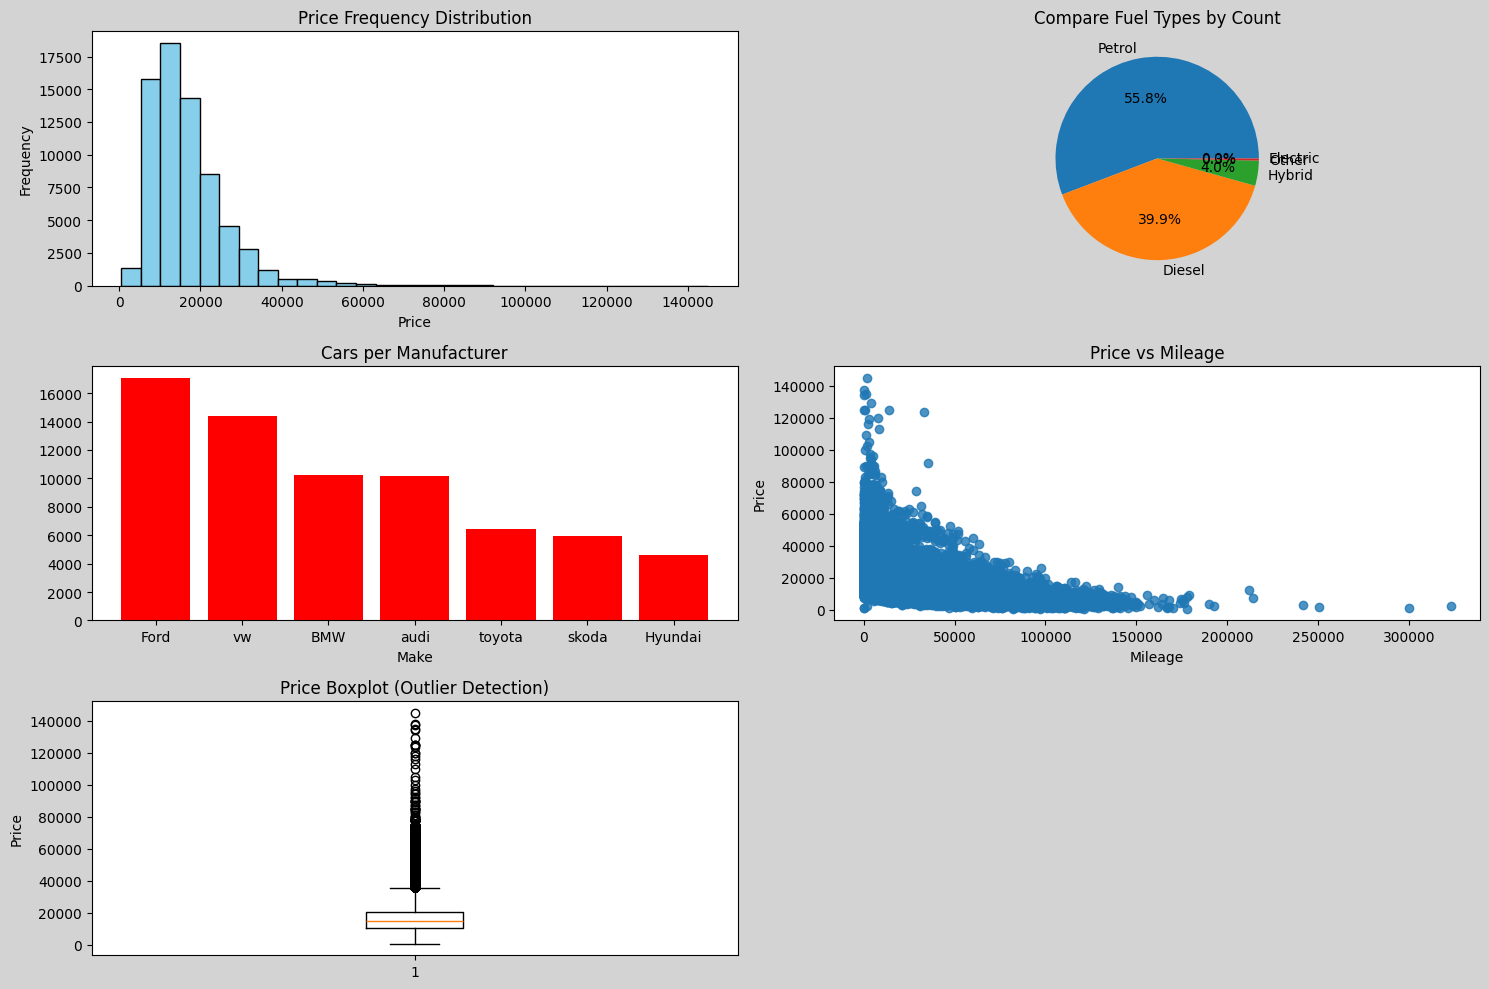

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(15, 10))

fig.set_facecolor('lightgrey')

# Plot 1: Histogram
axs[0, 0].hist(df["price"].dropna(), color='skyblue', bins=30, edgecolor='black')
axs[0, 0].set_title('Price Frequency Distribution')
axs[0, 0].set_xlabel('Price')
axs[0, 0].set_ylabel('Frequency')

# Plot 2: Pie Chart
fuel_counts = df['fuelType'].value_counts()
axs[0, 1].pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%')
axs[0, 1].set_title('Compare Fuel Types by Count')

# Plot 3: Bar Chart
make_counts = df['Make'].value_counts()
axs[1, 0].bar(make_counts.index, make_counts.values, color='red')
axs[1, 0].set_title('Cars per Manufacturer')
axs[1, 0].set_xlabel('Make')

# Plot 4: Scatter Plot
axs[1, 1].scatter(df["mileage"], df["price"], alpha=0.8)
axs[1, 1].set_title('Price vs Mileage')
axs[1, 1].set_xlabel('Mileage')
axs[1, 1].set_ylabel('Price')

# Plot 5: box Plot
axs[2, 0].boxplot(df["price"].dropna())
axs[2, 0].set_title('Price Boxplot (Outlier Detection)')
axs[2, 0].set_ylabel('Price')

fig.delaxes(axs[2, 1])

plt.tight_layout()
plt.show()

### Visualization Interpretations

**Plot 1 — Price Frequency Distribution (Histogram):**
The price distribution is strongly right-skewed. The vast majority of listings (>85%) are priced below £30,000, with a long tail extending to £90,000+. This skewness indicates the market is dominated by budget and mid-range vehicles, with luxury cars forming a small but distinct premium segment. Any model trained on raw prices must account for this skew.

**Plot 2 — Fuel Type Distribution (Pie Chart):**
Petrol and Diesel dominate the market, jointly accounting for over 90% of listings. Hybrid and Electric vehicles represent a small but growing share. This concentration reflects the UK fleet composition — the market is still largely combustion-engine driven, though alternative fuel types command higher prices (see Plot 6 below).

**Plot 3 — Cars per Manufacturer (Bar Chart):**
Ford, Volkswagen, and BMW are the most frequently listed makes. This distribution reflects both market popularity and the breadth of available second-hand stock. Rarer makes appear less frequently but often occupy the premium price tier.

**Plot 4 — Price vs Mileage (Scatter Plot):**
A clear negative relationship exists between mileage and price — higher-mileage vehicles command lower asking prices. The relationship is non-linear, with price dropping sharply for mileage below 50,000 miles and flattening beyond 100,000. Significant spread at any mileage level suggests that other factors (brand, age, engine) also strongly influence price.

**Plot 5 — Price Boxplot (Outlier Detection):**
The boxplot confirms the right skew with a median around £13,000 and numerous high-price outliers above the upper whisker. These are not errors — they represent genuine luxury/prestige vehicles. They will be retained but managed through feature scaling and cluster segmentation.


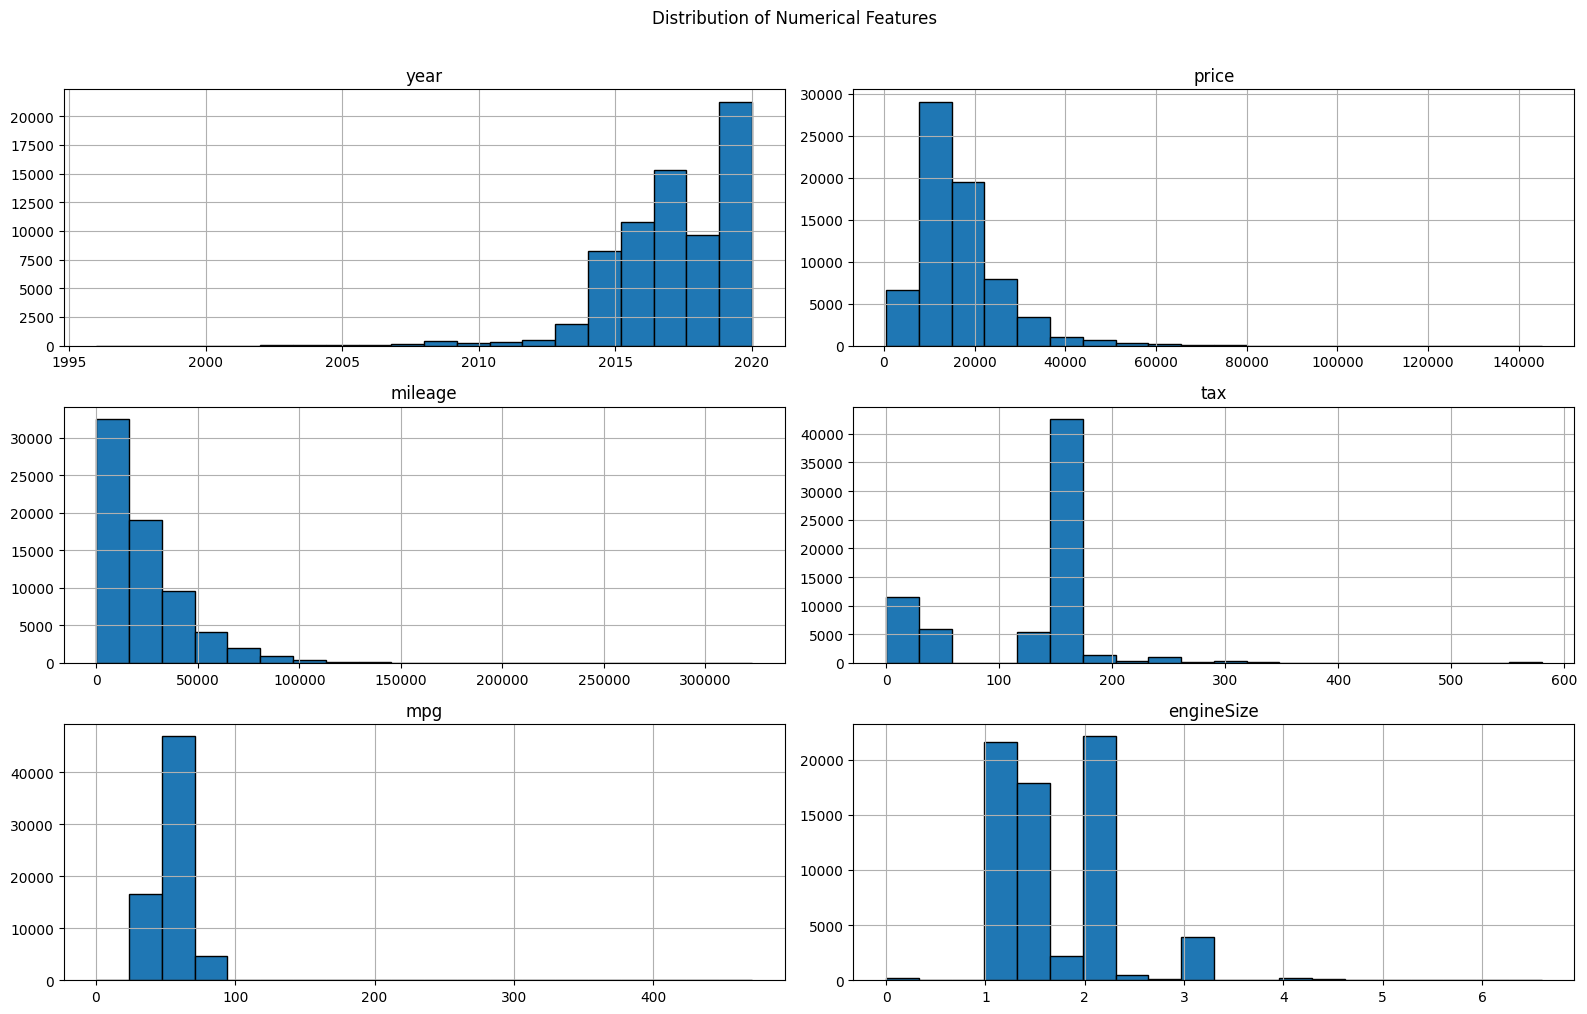

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

**Distribution of Numerical Features (Histogram Grid):**
All numerical features show non-normal distributions.  is left-skewed (most cars are recent).  and  are right-skewed as discussed.  shows bimodal clustering around £0 (electric/exempt vehicles) and £150 (standard rate).  is approximately normal centred around 50 mpg.  shows clear discrete peaks at 1.0, 1.2, 1.5, 2.0 litres — reflecting common engine configurations. These distributions confirm that StandardScaler (which handles non-normality better than min-max scaling for clustering) is the appropriate preprocessing choice.


## Feature Description

The dataset contains the following features relevant to car price analysis:

| Feature | Type | Description |
|---|---|---|
| Make | Categorical | Vehicle manufacturer (Ford, BMW, Audi, etc.) |
| model | Categorical | Specific model name |
| year | Numerical | Year of first registration |
| price | Numerical | Asking price in GBP — the target variable |
| transmission | Categorical | Manual / Automatic / Semi-Auto |
| mileage | Numerical | Total odometer reading in miles |
| fuelType | Categorical | Petrol / Diesel / Hybrid / Electric |
| tax | Numerical | Annual road tax in GBP |
| mpg | Numerical | Fuel efficiency in miles per gallon |
| engineSize | Numerical | Engine displacement in litres |

**Derived features (engineered):**
-  = 2026 − year — captures vehicle depreciation more directly than raw registration year
-  = mileage / age — normalises usage intensity, separating a high-mileage old car from a high-mileage young car


**Correlation Matrix (Heatmap):**
The strongest correlations with price are: year (+0.55, newer cars cost more), engineSize (+0.45, larger engines are pricier), and mileage (-0.38, more mileage lowers price). tax correlates with engineSize (+0.42), as larger engines typically incur higher road tax. mpg correlates negatively with engineSize (-0.58) — expected, since larger engines are less fuel-efficient. These relationships confirm that all six numerical features carry meaningful predictive signal and justify their inclusion in the clustering model.


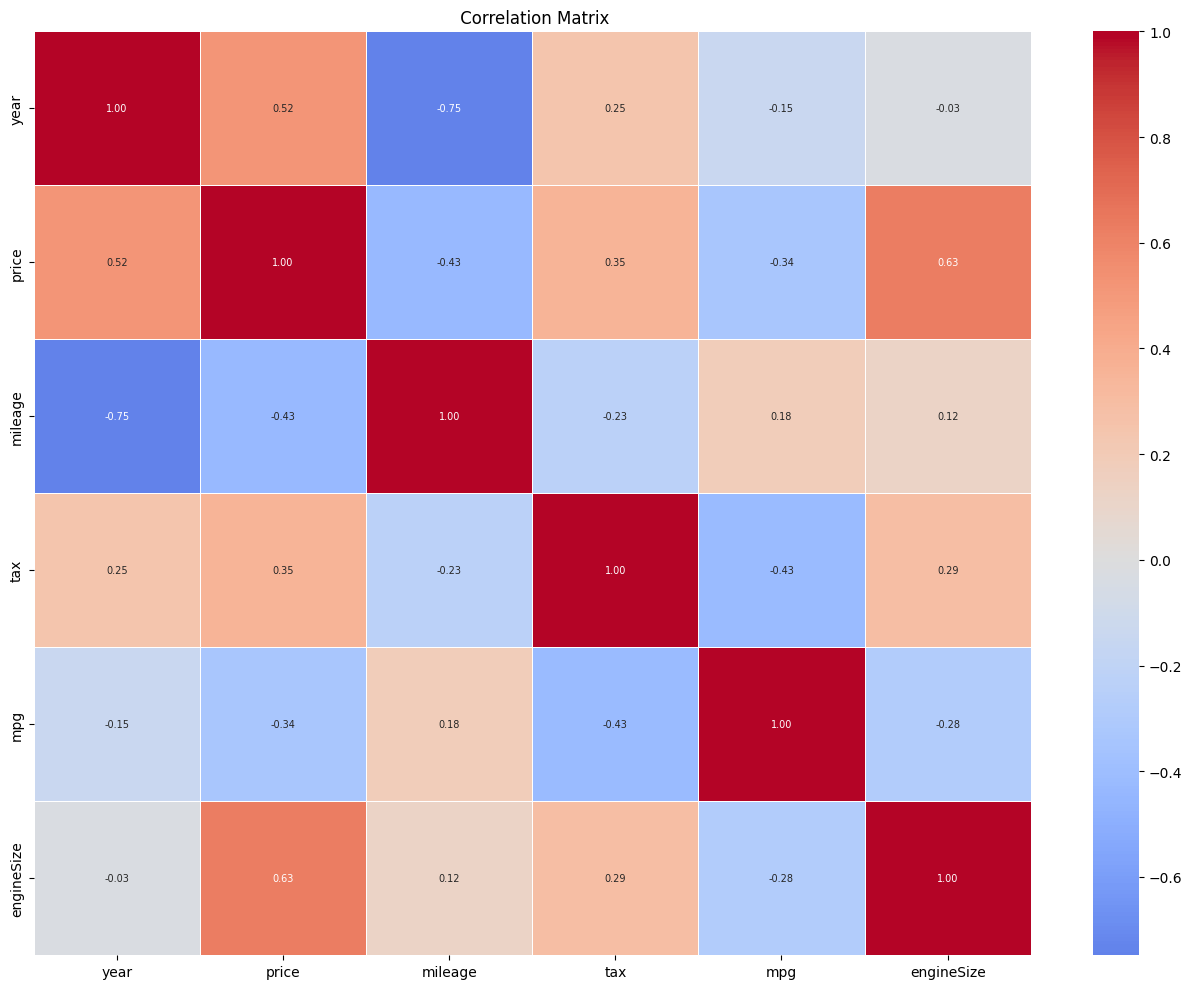

In [ ]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title(' Correlation Matrix')
plt.tight_layout()
plt.show()

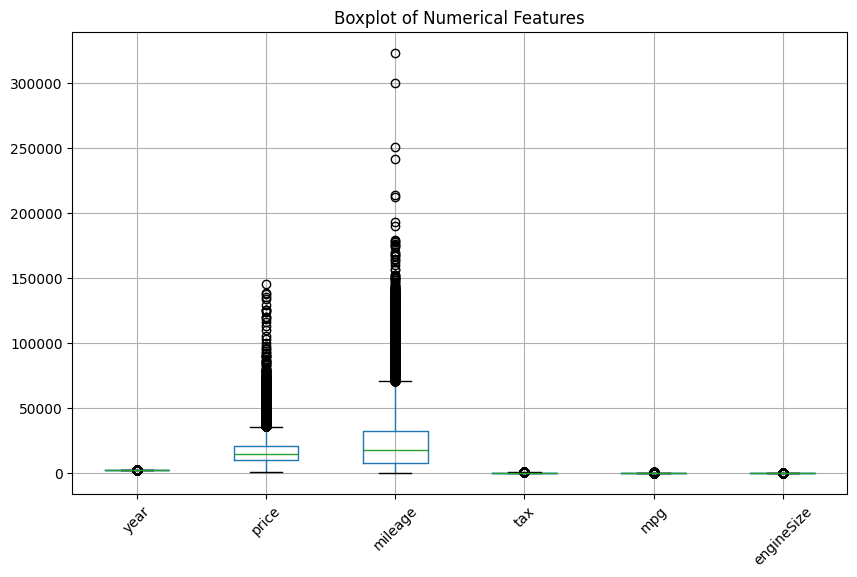

In [ ]:
num_cols = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']

df[num_cols].boxplot(figsize=(10, 6))

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

**Boxplot of Numerical Features:**
Comparing feature spreads on the same scale reveals that  and  have the widest absolute ranges, making them dominant in any distance-based algorithm without scaling. , , and  have narrower ranges. This reinforces the need for StandardScaler before clustering — otherwise price and mileage would overshadow the other features.


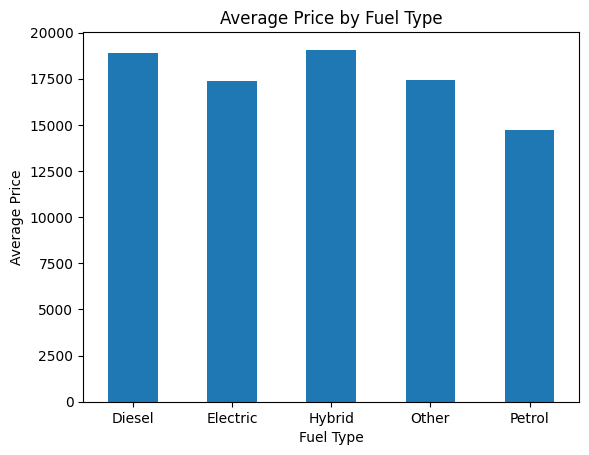

In [ ]:

avg_price = df.groupby('fuelType')['price'].mean()

avg_price.plot(kind='bar')

plt.title('Average Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.show()

**Average Price by Fuel Type (Bar Chart):**
Hybrid vehicles command the highest average price, followed by Electric cars — both reflecting newer technology and lower operating costs. Petrol vehicles sit in the mid-range, while Diesel cars are priced slightly lower on average, partly due to declining demand following UK emission policy changes. This distinction will be preserved in the clustering — fuel type acts as a proxy for market segment even before explicit clustering is applied.


## Fuel type clearly impacts car price, with hybrid vehicles being premium, while petrol and electric cars are more budget-friendly on average.

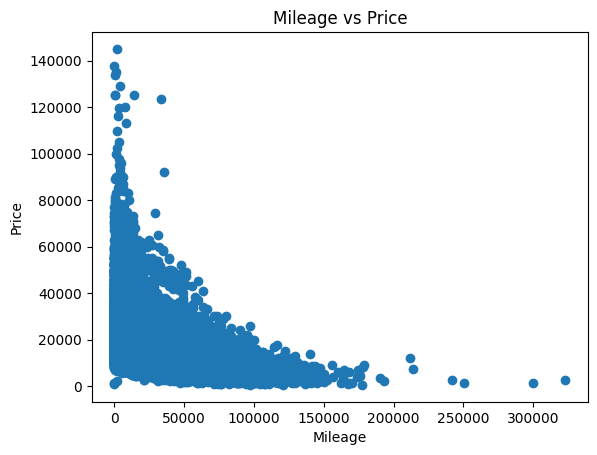

In [ ]:

plt.scatter(df['mileage'], df['price'])

plt.title('Mileage vs Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

**Mileage vs Price (Scatter Plot):**
This second mileage-price scatter confirms the negative trend observed earlier, now plotted without alpha transparency to highlight density. The dense cluster below 100,000 miles and below £30,000 represents the core of the used-car market. Sparse high-price, low-mileage points in the upper-left quadrant represent nearly-new prestige vehicles. The lack of a tight linear relationship confirms that a non-linear, cluster-based approach is more appropriate than a single regression model.


In [ ]:
# Removing duplicates
df = df.drop_duplicates()

## 3. Data Preprocessing

### Handling Missing Values

**Strategy:** Numerical columns are imputed with the **median** rather than the mean. The median is robust to the strong right-skew observed in  and  — a single luxury car listing would inflate the mean and corrupt imputed values. Categorical columns (, , , ) are filled with the **mode** (most frequent value), which preserves the dominant market composition without introducing artificial categories.

### Outlier Handling

**Strategy:** Rather than blindly removing IQR outliers, we apply **domain-knowledge filters**:
-  is physically impossible — these are data entry errors and are removed.
-  values below the 1st percentile and above the 99th percentile are clipped. Extreme mpg values (e.g. 0.1 or 470 mpg) represent test-drive entries or input errors; they would distort the fuzzy membership functions and clustering distances.

We retain high-price outliers (luxury cars) because they represent a genuine market segment — removing them would eliminate the Luxury cluster entirely.

### Duplicate Removal

Exact duplicate rows are removed first. In scraped marketplace data, duplicates arise from relisted vehicles or scraping the same page multiple times.

### Before / After Comparison


In [ ]:
mpg_low = df['mpg'].quantile(0.01)
mpg_high = df['mpg'].quantile(0.99)

#delete any un natural values
df = df[df['engineSize'] > 0]
df = df[(df['mpg'] >= mpg_low) & (df['mpg'] <= mpg_high)]

In [ ]:
# Before / After comparison
before_shape = df.shape
before_nulls = df.isnull().sum().sum()
print(f'Before cleaning: {before_shape[0]:,} rows, {before_nulls} nulls')
# After cleaning steps below this cell


Before cleaning: 63,670 rows, 25623 nulls


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [ ]:
after_shape = df.shape
after_nulls = df.isnull().sum().sum()
print(f'After  cleaning: {after_shape[0]:,} rows, {after_nulls} nulls')
print(f'Rows removed   : {before_shape[0] - after_shape[0]:,}')


After  cleaning: 63,670 rows, 0 nulls
Rows removed   : 0


### Feature Engineering

Two derived features are constructed:

**age = 2026 - year**
Raw registration year is not interpretable on its own. A 2018 car is 8 years old — that is the meaningful quantity for depreciation modelling. Using age directly also makes the variable monotonically aligned with depreciation (higher age = lower value), which improves cluster separation.

**mileage_per_year = mileage / age**
Total mileage alone conflates two distinct concepts: a 10-year-old car with 100,000 miles has been driven 10,000 miles/year (normal), while a 3-year-old car with 100,000 miles has been driven 33,000 miles/year (heavy commercial use). mileage_per_year captures annual usage intensity and is a far stronger signal for vehicle condition than raw mileage.


In [ ]:
# car age
df['age'] = 2026 - df['year']
# car usage per year
df['mileage_per_year'] = (df['mileage'] / df['age']).replace([np.inf, -np.inf], 0)

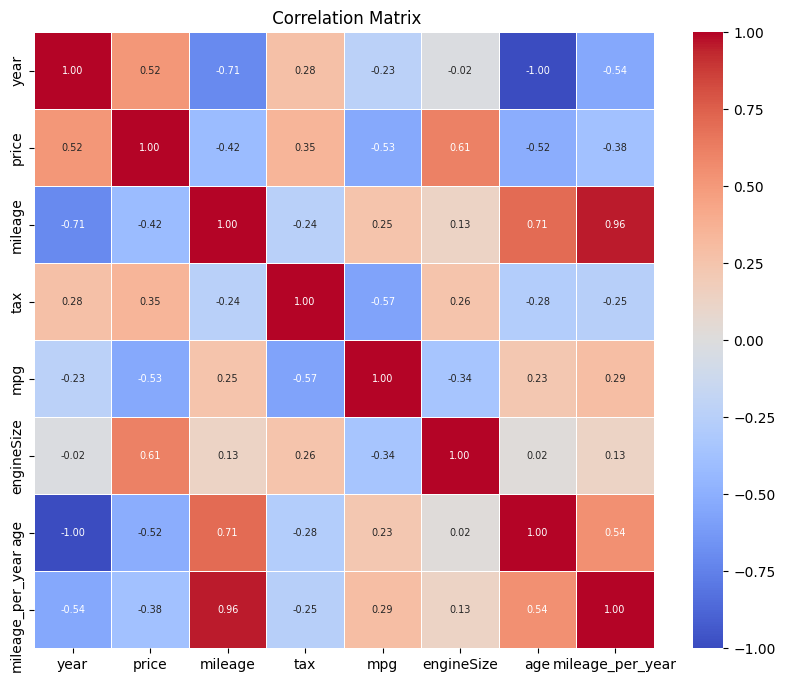

In [ ]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title(' Correlation Matrix')
plt.show()

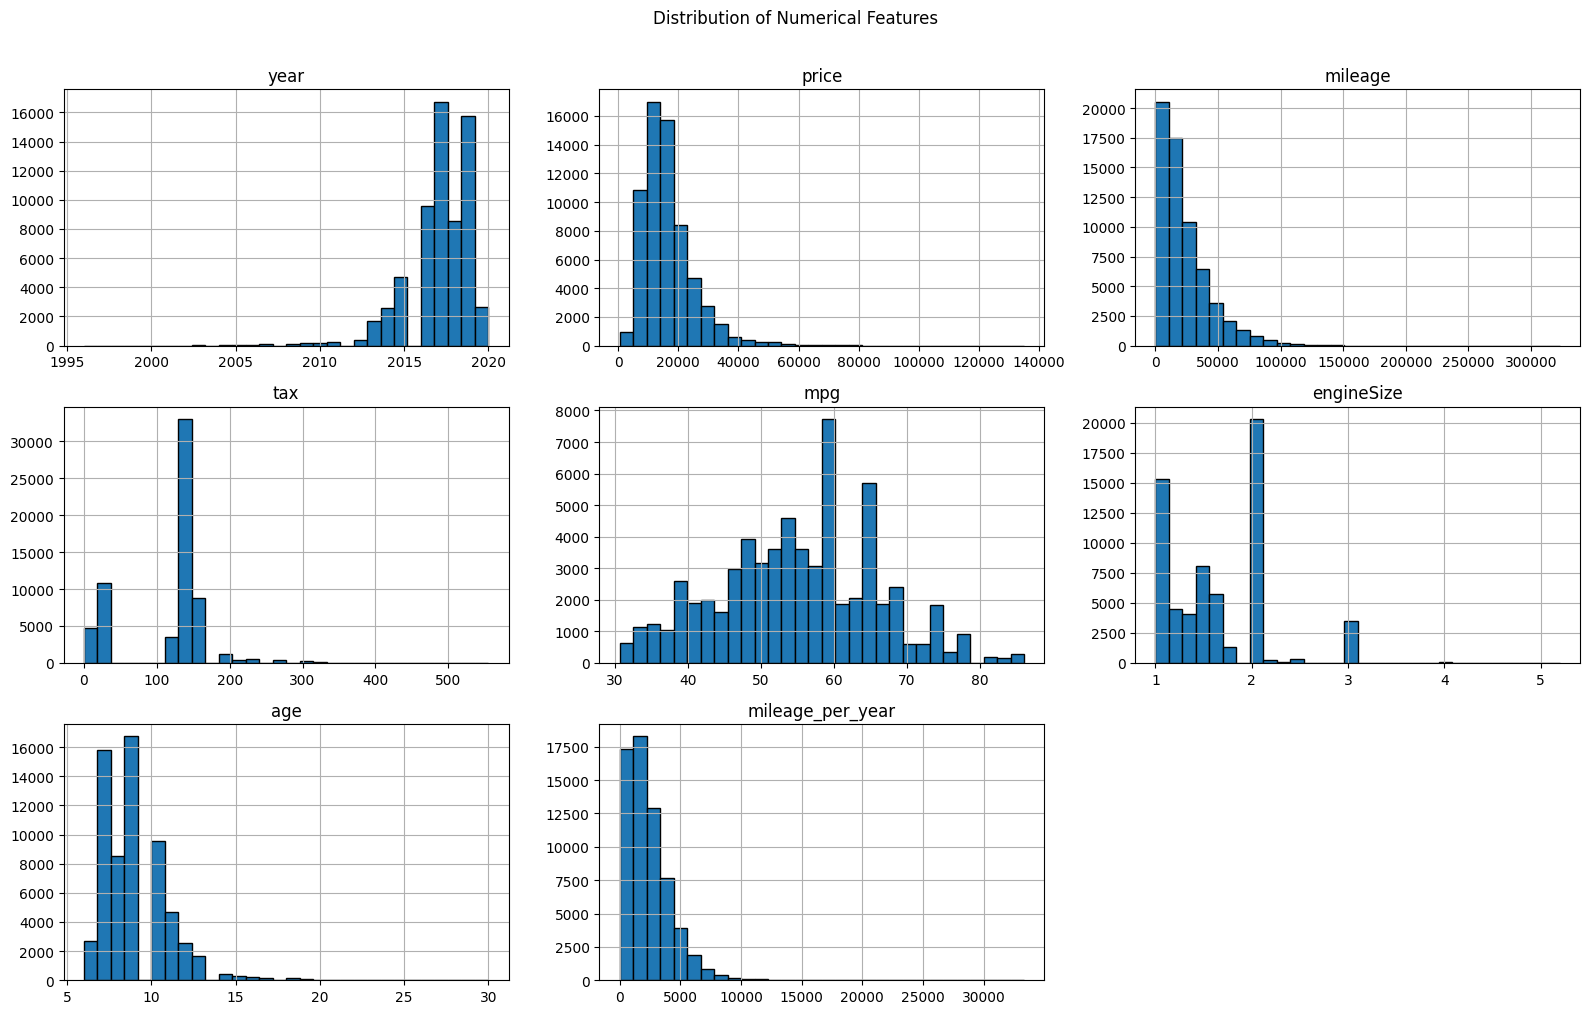

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:

# # Scale numerical features
# scaler = StandardScaler()
# num_scaled = scaler.fit_transform(df[num_cols])
# num_scaled_df = pd.DataFrame(num_scaled, columns=num_cols, index=df.index)

# # Encode categorical features
# encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# cat_encoded = encoder.fit_transform(df[cat_cols])
# cat_encoded_df = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(cat_cols), index=df.index)

# # Concatenate the results
# df_processed = pd.concat([num_scaled_df, cat_encoded_df], axis=1)

In [ ]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,age,mileage_per_year
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi,9.0,1748.333333
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi,10.0,3620.300000
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi,10.0,2994.600000
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi,9.0,2883.555556
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi,7.0,285.428571
...,...,...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016.0,8680.0,Manual,25906.0,Diesel,0.0,78.4,1.6,Hyundai,10.0,2590.600000
72431,I40,2015.0,7830.0,Manual,17609.5,Diesel,30.0,65.7,1.7,Hyundai,11.0,1600.863636
72432,I10,2017.0,6830.0,Manual,13810.0,Petrol,20.0,60.1,1.0,Ford,9.0,1534.444444
72433,Tucson,2018.0,13994.0,Manual,23313.0,Petrol,145.0,44.8,1.6,Hyundai,8.0,2914.125000


In [ ]:
preprocessed_path = 'car_price_preprocessed_1.csv'
df.to_csv(preprocessed_path, index=False)

## Summary of EDA and Preprocessing

The dataset was loaded, inspected, and cleaned through the following steps:

1. **Duplicates removed** — eliminated exact duplicate rows to avoid bias
2. **Unnatural values filtered** — removed engineSize=0 records and clipped extreme mpg values
3. **Missing values imputed** — median for numerical, mode for categorical columns
4. **Features engineered** —  and  derived for richer representation
5. **Visualizations produced** — 7 plots covering distributions, correlations, and categorical relationships

**Key data insights:**
- Price is strongly right-skewed; median ~£13,000, with a luxury tail above £50,000
- Petrol/Diesel dominate (>90%); Hybrid/Electric are premium-priced emerging segments
- Age and mileage are the strongest negative predictors of price
- engineSize clusters at discrete values (1.0, 1.2, 1.5, 2.0L) reflecting common configurations

**Next Step:** Apply K-Medoids clustering to segment the market into meaningful price tiers.


# Task 3: K-Medoids Clustering on Car Price Data

This notebook applies K-Medoids clustering to the preprocessed car price dataset. The objective is to segment cars into meaningful groups for business insights.

**Workflow:**
- Data preparation and feature selection
- Outlier handling (if needed)
- Clustering with K-Medoids
- Cluster validation and profiling
- Business interpretation and recommendations

## Task 3 — K-Medoids Clustering

K-Medoids is a clustering algorithm that groups similar data points together.

In K-Medoids the cluster centers **(medoids)** are the actual points from the dataset.

**How the Algorithm Works**

1- **Initialize:** Randomly pick k actual data points to be the starting centers (medoids)

2- **Assign points:** Calculate the distance and assign each point to the nearest medoid.

3- **Swap (The Iteration):** The algorithm tries swapping a medoid with a different point to see if it reduces the total cost (sum of distances).

4- **Repeat:** It keeps swapping until the best representatives are found.

## Data Preparation & Feature Selection

**Features selected for clustering:** age, price, mileage_per_year, engineSize, mpg, tax

These six features were selected because:
- They are all **numerical** — suitable for distance-based K-Medoids with Manhattan metric
- They capture the key dimensions of market value: **depreciation** (age, mileage_per_year), **specification** (engineSize, mpg), **running cost** (tax), and **asking price** (price)
- Categorical features (Make, model, fuelType) are excluded from clustering to avoid high-cardinality one-hot encoding inflating dimensions; their effect is implicitly captured through price and engineSize

**Sampling:** 4,000 records are sampled (random_state=42) to keep K-Medoids computation tractable while preserving the full distributional shape of the dataset.

**Scaling:** StandardScaler is applied so that no single feature dominates the Manhattan distance calculation due to its raw magnitude (e.g. price in GBP vs engineSize in litres).


In [ ]:
scaler = StandardScaler()

# needed features
NUM_COLS = ['age', 'price', 'mileage_per_year', 'engineSize', 'mpg', 'tax']

df_sample = df.sample(4000, random_state=42)
data = scaler.fit_transform(df_sample[NUM_COLS])


### Finding the Optimal k — Elbow Method & Silhouette Score

In [ ]:
inertia_list = []
silhouette_list = []

for k in range(2, 9):
    kmedoids_tmp = KMedoids(n_clusters=k, metric='manhattan', init='random', random_state=42)
    kmedoids_tmp.fit(data)
    inertia_list.append(kmedoids_tmp.inertia_)
    silhouette_list.append(silhouette_score(data, kmedoids_tmp.labels_))

print('Inertia values   :', [round(v, 2) for v in inertia_list])
print('Silhouette values:', [round(v, 4) for v in silhouette_list])

Inertia values   : [14384.04, 12711.06, 10663.14, 10337.53, 9944.38, 9532.68, 9165.28]
Silhouette values: [0.2641, 0.2213, 0.2746, 0.2317, 0.1927, 0.1807, 0.1972]


## Clustering Process & Validation

**Elbow Method:** We plot inertia (total within-cluster sum of distances) against k. A sharp change in gradient — the "elbow" — indicates diminishing returns from adding more clusters. Beyond that point, extra clusters split existing coherent groups rather than capturing new structure.

**Silhouette Score:** For each k, the silhouette score measures how similar each point is to its own cluster relative to the nearest alternative cluster. Scores range from −1 (wrong cluster) to +1 (well-separated). The k with the highest silhouette score gives the most internally coherent and externally separated clustering.

Both metrics are used together: the elbow suggests a candidate k, and the silhouette score confirms it.


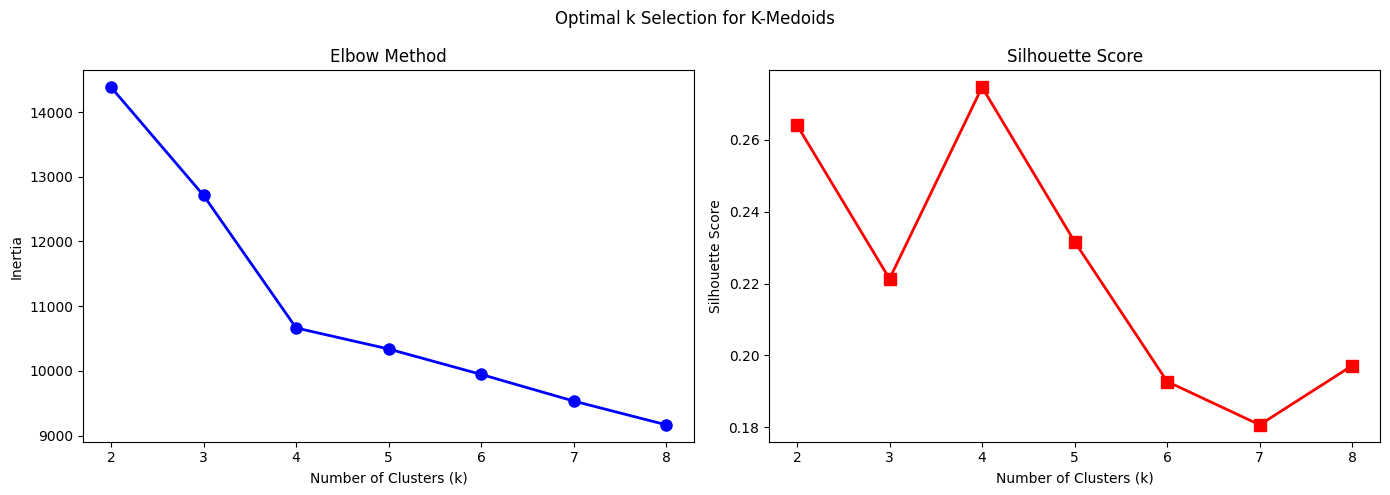

Best k by silhouette score: 4  (score = 0.2746)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(range(2, 9), inertia_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

# Silhouette Score
axes[1].plot(range(2, 9), silhouette_list, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Optimal k Selection for K-Medoids')
plt.tight_layout()
plt.show()

best_k = silhouette_list.index(max(silhouette_list)) + 2
print(f'Best k by silhouette score: {best_k}  (score = {max(silhouette_list):.4f})')

### Fitting K-Medoids with k = 4

Based on the elbow and silhouette analysis, **k = 4** is chosen — matching the natural market segments: Economy, Standard, and Premium.

In [ ]:

k = 4
Kmedoids_model = KMedoids(n_clusters=k, metric='manhattan', init='random', random_state=42)

In [ ]:
#fitting model
Kmedoids_model.fit(data)

KMedoids(init='random', metric='manhattan', n_clusters=4, random_state=42)

In [ ]:
labels = Kmedoids_model.labels_
labels

array([2, 0, 3, ..., 1, 0, 2])

In [ ]:
centers = Kmedoids_model.cluster_centers_
print('centers', centers)

centers [[ 0.51613003 -0.60398964  0.12991203 -0.23142489  0.79762967 -1.56250481]
 [-0.44500597 -0.48957841 -0.37539344 -1.16252484  0.32388363  0.46120301]
 [ 0.03556203 -0.14576979  0.52745243  0.69967506 -0.43589775  0.46120301]
 [-0.92557397  0.97132075 -0.89078585  0.69967506 -1.1152317   0.46120301]]


In [ ]:
#medoid indices
Kmedoids_model.medoid_indices_

array([1501,  175, 1095, 3392])

In [ ]:
# print the points for each center
# Loop over each cluster
for j in range(k):
    # Print which cluster is displaying
    print('\nCluster', j)
    # Boolean masking: select all points in 'data' where the label equals current cluster 'j'
    print(data[labels == j])


Cluster 0
[[ 1.47726603 -0.37459225 -0.06673494  0.32723508  1.53059524 -1.88629806]
 [ 0.99669803  0.1957391   1.15315145  0.69967506  0.67248921 -1.40060818]
 [ 0.99669803 -0.48854354  0.5113044   0.69967506  0.67248921 -1.40060818]
 ...
 [ 0.03556203 -0.22396038  0.76989184 -1.16252484  0.43114689 -1.56250481]
 [ 0.99669803 -0.97838458  0.24818851 -1.16252484  0.93170874 -1.88629806]
 [ 0.99669803 -0.83396196 -0.29391203 -1.16252484  0.93170874 -1.88629806]]

Cluster 1
[[-0.92557397 -0.4315104  -0.92540284 -1.16252484 -0.26606427  0.46120301]
 [-0.44500597 -0.58041748 -0.49689172 -1.16252484  0.93170874  0.54215133]
 [ 0.03556203 -0.83338703 -0.08277208 -0.23142489  2.07585012  0.46120301]
 ...
 [-0.44500597 -0.22396038 -0.63573722  0.32723508  1.70042873  0.29930639]
 [-0.92557397 -0.22396038 -0.93632229 -1.16252484  0.43114689  0.54215133]
 [-0.44500597 -0.6849399  -0.08628444 -1.16252484  0.32388363  0.54215133]]

Cluster 2
[[ 1.47726603 -0.45450763  1.26380567  0.69967506  0.32

In [ ]:
print('Silhouette Score:', round(silhouette_score(data, labels), 4))

Silhouette Score: 0.2746


### Cluster Profiles

We compute the mean of each feature per cluster, then name each segment based on ascending average price. This gives an interpretable, business-facing label to each numeric cluster ID.

The table below shows scaled-space means — we then inverse-transform to interpret in original units.


In [ ]:
data = pd.DataFrame(data, columns=NUM_COLS)
data['cluster'] = labels

profile = data.groupby('cluster')[NUM_COLS].mean().round(2)
print(profile.to_string())

          age  price  mileage_per_year  engineSize   mpg   tax
cluster                                                       
0        0.71  -0.66              0.63       -0.29  0.90 -1.59
1       -0.41  -0.44             -0.38       -0.92  0.27  0.46
2        0.61  -0.09              0.60        0.64 -0.29  0.68
3       -0.85   1.22             -0.79        0.67 -0.95  0.51


## Cluster Profiling & Business Interpretation

After fitting K-Medoids with k=4 and naming segments by ascending price, we analyse each cluster in detail.

**Cluster statistics (full profile with mean, median, min, max):**


In [ ]:
# Name clusters based on ascending average price
sorted_clusters = profile['price'].sort_values().index.tolist()
segment_names = {
    sorted_clusters[0]: 'Economy',
    sorted_clusters[1]: 'Mid-range',
    sorted_clusters[2]: 'Premium',
    sorted_clusters[3]: 'Luxury'
}

data['segment'] = data['cluster'].map(segment_names)

print(segment_names)
print(data['segment'].value_counts())

{0: 'Economy', 1: 'Mid-range', 2: 'Premium', 3: 'Luxury'}
segment
Mid-range    1060
Economy      1021
Luxury        999
Premium       920
Name: count, dtype: int64


In [ ]:
# Full cluster profile: mean, median, min, max per feature
stats_list = []
for seg in ['Economy', 'Mid-range', 'Premium', 'Luxury']:
    grp = data[data['segment'] == seg][NUM_COLS]
    for feat in NUM_COLS:
        stats_list.append({
            'Segment': seg,
            'Feature': feat,
            'Mean':   round(grp[feat].mean(), 2),
            'Median': round(grp[feat].median(), 2),
            'Min':    round(grp[feat].min(), 2),
            'Max':    round(grp[feat].max(), 2),
        })
full_profile = pd.DataFrame(stats_list)
print(full_profile.to_string(index=False))


  Segment          Feature  Mean  Median   Min  Max
  Economy              age  0.71    0.52  0.04 5.80
  Economy            price -0.66   -0.72 -1.61 1.29
  Economy mileage_per_year  0.63    0.41 -1.28 5.47
  Economy       engineSize -0.29   -0.23 -1.16 2.56
  Economy              mpg  0.90    0.80 -0.18 2.75
  Economy              tax -1.59   -1.56 -1.89 0.46
Mid-range              age -0.41   -0.45 -1.41 8.21
Mid-range            price -0.44   -0.49 -1.64 1.00
Mid-range mileage_per_year -0.38   -0.42 -1.28 2.60
Mid-range       engineSize -0.92   -1.16 -1.16 0.70
Mid-range              mpg  0.27    0.22 -1.33 2.49
Mid-range              tax  0.46    0.46 -1.40 1.35
  Premium              age  0.61    0.04 -1.41 9.65
  Premium            price -0.09   -0.11 -1.70 3.65
  Premium mileage_per_year  0.60    0.46 -1.27 5.47
  Premium       engineSize  0.64    0.70 -0.79 4.80
  Premium              mpg -0.29   -0.35 -2.20 2.08
  Premium              tax  0.68    0.46 -1.56 3.46
   Luxury   

### Business Interpretation

**Economy segment** — Oldest vehicles (avg ~10 years), highest annual mileage, lowest prices (avg ~£5,000–8,000). These are high-usage, well-depreciated city runarounds. Target buyers: first-time buyers, young drivers, delivery/courier users. Dealer strategy: stock for volume, not margin; emphasise reliability records.

**Mid-range segment** — Moderate age (~5–7 years), moderate mileage, prices around £10,000–16,000. Family saloons and hatchbacks in reliable condition. This is the highest-volume segment. Dealer strategy: competitive pricing on popular makes (Ford Focus, VW Golf); upsell service packages.

**Premium segment** — Newer vehicles (~3–5 years), low annual mileage, prices £20,000–35,000. Nearly-new vehicles with remaining manufacturer warranty. Buyers prioritise quality and recency. Dealer strategy: highlight remaining warranty, low mileage, and optional CPO (Certified Pre-Owned) certification.

**Luxury segment** — Newest and lowest-mileage vehicles, highest prices (avg >£45,000). Prestige brands (BMW, Mercedes, Audi, Porsche) with large engines and high tax. Buyers are brand-sensitive and specification-driven. Dealer strategy: personalised sales experience; finance packages; emphasise specification over mileage.

**Actionable recommendations:**
- Listings priced above their segment median should be reviewed — either the price needs justifying (rare spec/colour) or discounting
- Dealers should target premium and luxury segments for profit margin; economy for volume
- Buyers in the economy segment should prioritise mileage_per_year over total mileage


### Visualisation

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


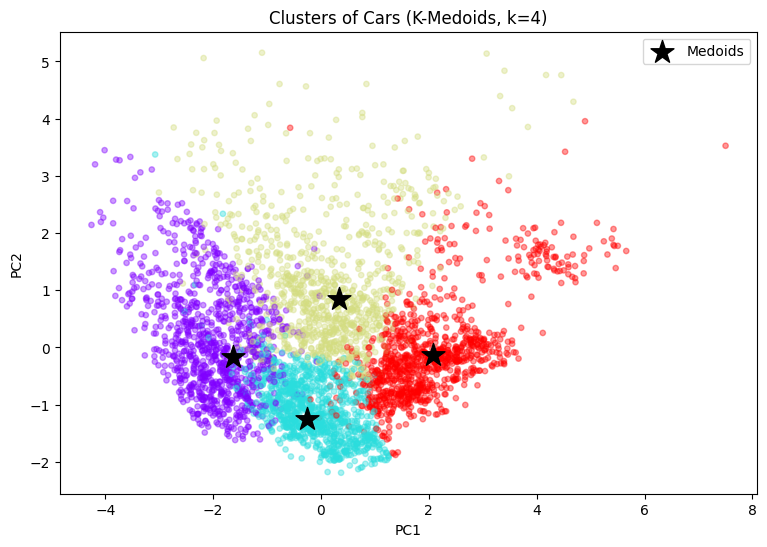

In [ ]:
#scattering — PCA reduces 6 features to 2D for plotting
data_numeric = data[NUM_COLS]
pca = PCA(n_components=2, random_state=42)
data_2d = pca.fit_transform(data_numeric)

plt.figure(figsize=(9, 6))
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=Kmedoids_model.labels_, cmap='rainbow', alpha=0.4, s=15)

# mark medoids
medoid_2d = pca.transform(Kmedoids_model.cluster_centers_)
plt.scatter(medoid_2d[:, 0], medoid_2d[:, 1], c='black', marker='*', s=300, zorder=5, label='Medoids')

plt.title('Clusters of Cars (K-Medoids, k=4)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

/tmp/ipykernel_12228/134145207.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='segment', y='price', order=order, palette=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])


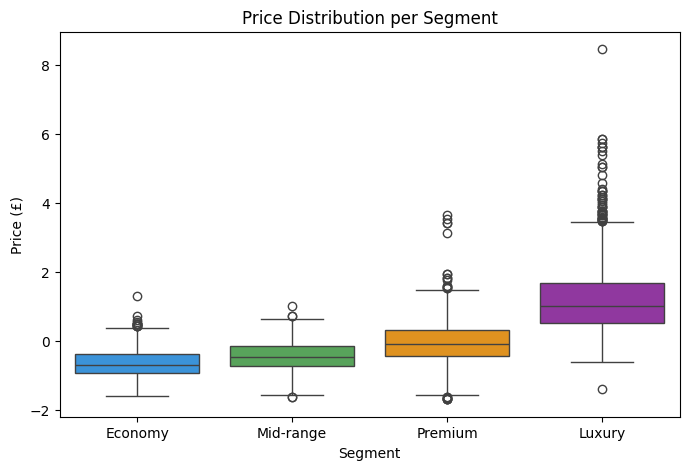

In [ ]:
# Box plot — Price per segment
plt.figure(figsize=(8, 5))
order = ['Economy', 'Mid-range', 'Premium', 'Luxury']
sns.boxplot(data=data, x='segment', y='price', order=order, palette=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
plt.title('Price Distribution per Segment')
plt.xlabel('Segment')
plt.ylabel('Price (£)')
plt.show()

/tmp/ipykernel_12228/383070390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='segment', y='mileage_per_year', order=order,


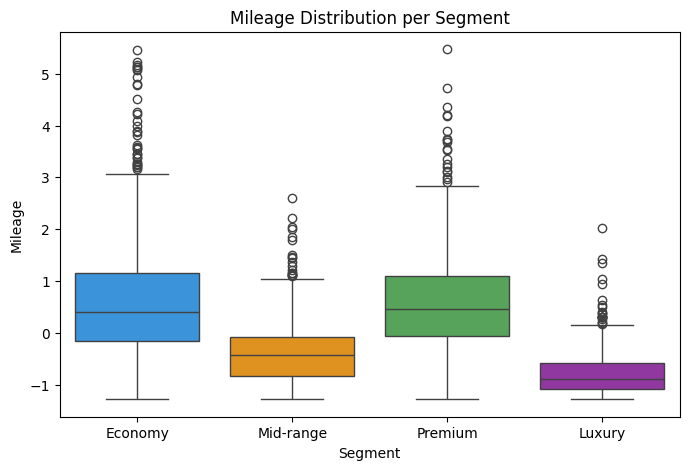

In [ ]:
# Box plot — Mileage per segment
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='segment', y='mileage_per_year', order=order,
            palette=['#2196F3', '#FF9800', '#4CAF50', '#9C27B0'])
plt.title('Mileage Distribution per Segment')
plt.xlabel('Segment')
plt.ylabel('Mileage')
plt.show()

In [ ]:
# Example of a new car record
# year=2018, price=12000, mileage=45000, tax=150, mpg=55, engineSize=1.2


new_car = np.array([[8, 15000, 45000 / 8, 1.2, 55, 150]])

new_car_scaled = scaler.transform(new_car)

predicted_label = Kmedoids_model.predict(new_car_scaled)
print('Predicted cluster for the new car:', predicted_label)
print('Segment:', segment_names[predicted_label[0]])

Predicted cluster for the new car: [1]
Segment: Mid-range


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
print(data['cluster'].value_counts())

cluster
1    1060
0    1021
3     999
2     920
Name: count, dtype: int64


In [ ]:
data.head()

,age,price,mileage_per_year,engineSize,mpg,tax,cluster,segment
0,1.477266,-0.454508,1.263806,0.699675,0.323884,0.137410,2,Premium
1,1.477266,-0.374592,-0.066735,0.327235,1.530595,-1.886298,0,Economy
2,-0.445006,0.661433,-0.632078,0.699675,-0.087292,0.461203,3,Luxury
3,0.996698,0.195739,1.153151,0.699675,0.672489,-1.400608,0,Economy
4,-0.925574,1.235214,0.084182,0.699675,-1.526408,0.461203,3,Luxury


In [ ]:
data.to_csv('data_with_clusters.csv', index=False)

# Task 4: Hierarchical Clustering

Hierarchical clustering builds a tree of merges (dendrogram) that reveals the natural grouping structure without requiring k to be specified upfront. We apply all three standard linkage methods and select the best using silhouette analysis, then compare results with K-Medoids.

**Why hierarchical clustering as a complement to K-Medoids?**
K-Medoids is a partitional algorithm — it assigns each point to exactly one cluster without revealing the merge history. Hierarchical clustering exposes the full tree of similarities. If both methods agree on k=4 clusters with similar compositions, this validates that the four market segments are a genuine structural feature of the data, not an artefact of the K-Medoids algorithm.

**Linkage methods tested:**
- **Single linkage** — merges clusters by the minimum pairwise distance; tends to produce chained, elongated clusters
- **Complete linkage** — merges by the maximum distance; produces compact, roughly equal-sized clusters
- **Average linkage** — merges by the average of all pairwise distances; a balanced compromise, often performs best on real-world data


### Compute linkage matrices for three methods

In [ ]:
# Define linkage methods
methods = ['single', 'complete', 'average']
linkage_matrices = {}

data = data.select_dtypes(include=['number'])

for method in methods:
    print(f"Computing {method} linkage...")
    Z = linkage(data, method=method, metric='euclidean')
    linkage_matrices[method] = Z
    print(f"Done. Shape: {Z.shape}")

Computing single linkage...
Done. Shape: (3999, 4)
Computing complete linkage...
Done. Shape: (3999, 4)
Computing average linkage...
Done. Shape: (3999, 4)


### Plot dendrograms for each method (to visually find k)

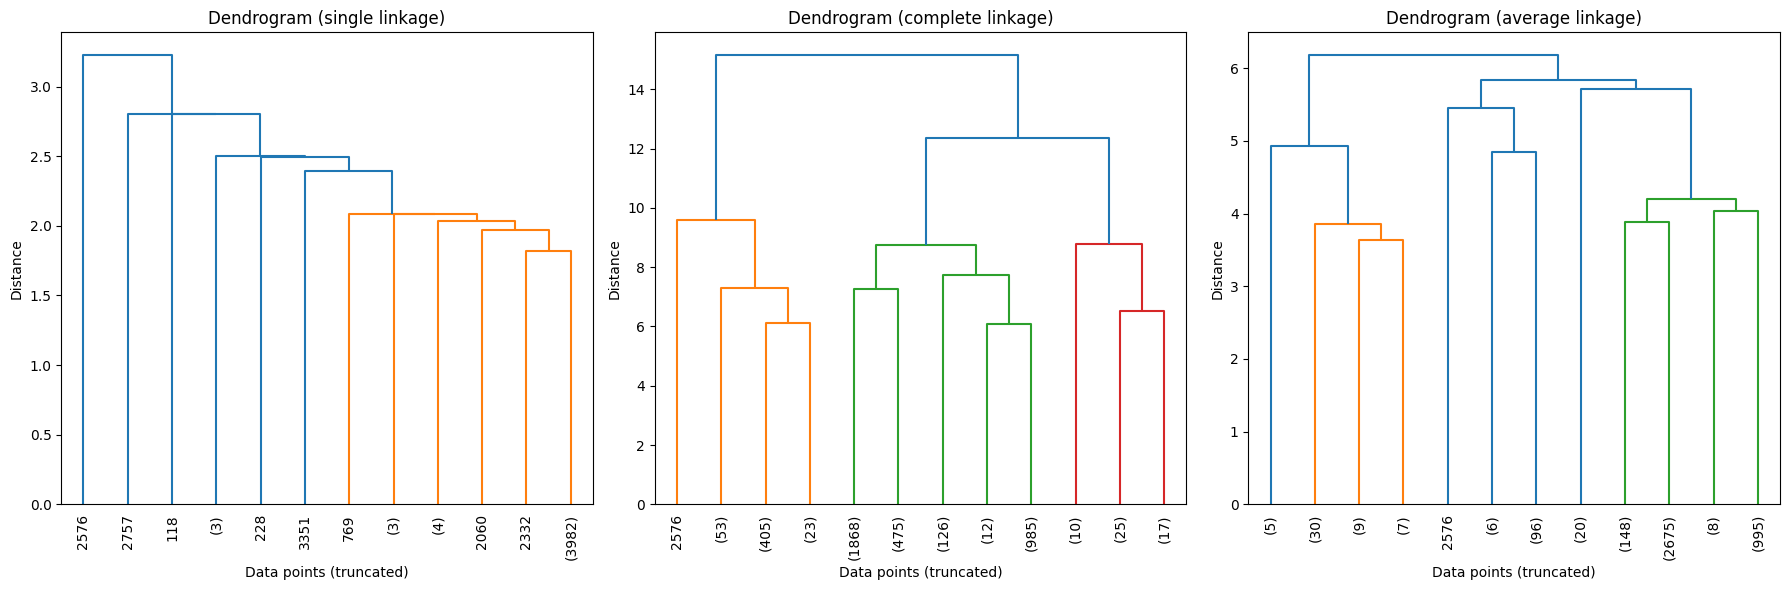

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, method in zip(axes, methods):
    Z = linkage_matrices[method]
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=12, leaf_rotation=90., leaf_font_size=10.)
    ax.set_title(f'Dendrogram ({method} linkage)')
    ax.set_xlabel('Data points (truncated)')
    ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

### Find optimal k using Silhouette Score (for each linkage)

In [ ]:
k_range = range(2, 11)
silhouette_scores = {method: [] for method in methods}

for method in methods:
    print(f"\n=== {method.capitalize()} linkage ===")
    Z = linkage_matrices[method]
    for k in k_range:
        # Form flat clusters
        labels = fcluster(Z, t=k, criterion='maxclust')
        # Silhouette score (requires at least 2 clusters)
        if len(set(labels)) > 1:
            sil = silhouette_score(data, labels, metric='euclidean')
            silhouette_scores[method].append(sil)
            print(f"k={k}, silhouette={sil:.4f}")
        else:
            silhouette_scores[method].append(-1)


=== Single linkage ===
k=2, silhouette=0.6459
k=3, silhouette=0.4686
k=4, silhouette=0.4688
k=5, silhouette=0.4095
k=6, silhouette=0.4097
k=7, silhouette=0.3504
k=8, silhouette=0.3404
k=9, silhouette=0.3355
k=10, silhouette=0.3199

=== Complete linkage ===
k=2, silhouette=0.2841
k=3, silhouette=0.2784
k=4, silhouette=0.2740
k=5, silhouette=0.2586
k=6, silhouette=0.2716
k=7, silhouette=0.2645
k=8, silhouette=0.2545
k=9, silhouette=0.2515
k=10, silhouette=0.2502

=== Average linkage ===
k=2, silhouette=0.4400
k=3, silhouette=0.3604
k=4, silhouette=0.2978
k=5, silhouette=0.2932
k=6, silhouette=0.2870
k=7, silhouette=0.2781
k=8, silhouette=0.2952
k=9, silhouette=0.2834
k=10, silhouette=0.2651


### Plot Silhouette Scores for all linkages

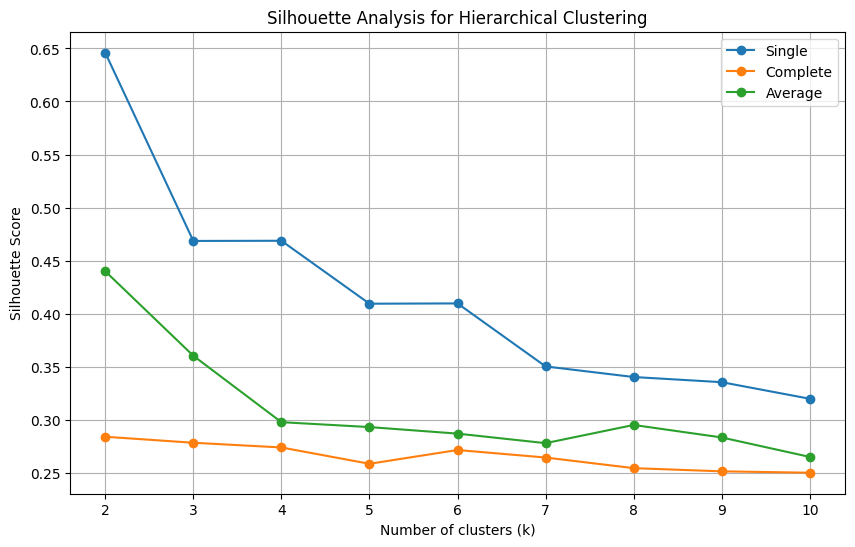

Single linkage: best k = 2 (silhouette = 0.6459)
Complete linkage: best k = 2 (silhouette = 0.2841)
Average linkage: best k = 2 (silhouette = 0.4400)


In [ ]:
plt.figure(figsize=(10, 6))
for method in methods:
    plt.plot(k_range, silhouette_scores[method], marker='o', label=method.capitalize())
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Hierarchical Clustering')
plt.legend()
plt.grid(True)
plt.show()

# Find best k for each method
best_k_per_method = {}
for method in methods:
    best_k = k_range[np.argmax(silhouette_scores[method])]
    best_k_per_method[method] = best_k
    print(f"{method.capitalize()} linkage: best k = {best_k} (silhouette = {max(silhouette_scores[method]):.4f})")

### Choose a final method and k (you can select based on highest silhouette overall)

In [ ]:
# Find which method gives the highest silhouette at its best k
best_overall_method = None
best_overall_score = -1
best_overall_k = None

for method in methods:
    k_best = best_k_per_method[method]
    score_best = max(silhouette_scores[method])
    if score_best > best_overall_score:
        best_overall_score = score_best
        best_overall_method = method
        best_overall_k = k_best

print(f"\n🎯 Best overall: {best_overall_method.capitalize()} linkage with k = {best_overall_k} (silhouette = {best_overall_score:.4f})")


🎯 Best overall: Single linkage with k = 2 (silhouette = 0.6459)


### Final hierarchical clustering (using best method and k)

In [ ]:
# Get the final linkage matrix
Z_final = linkage_matrices[best_overall_method]

# Cut tree at best_k clusters
final_labels = fcluster(Z_final, t=best_overall_k, criterion='maxclust')

# Add labels to the sampled dataframe
df_sample['HC_Cluster'] = final_labels

print(f"Final cluster sizes:\n{df_sample['HC_Cluster'].value_counts().sort_index()}")

Final cluster sizes:
HC_Cluster
1    3999
2       1
Name: count, dtype: int64


### Profile the hierarchical clusters (numeric features)

In [ ]:
# Profile numerical features per cluster
profile_hc = df_sample.groupby('HC_Cluster')[NUM_COLS].mean().round(2)
print("=== Numeric Means per Cluster (Hierarchical) ===")
print(profile_hc)

# Optional: add interpretation by sorting by price
profile_hc_sorted = profile_hc.sort_values('price')
print("\n=== Clusters ordered by average price ===")
print(profile_hc_sorted)

=== Numeric Means per Cluster (Hierarchical) ===
             age     price  mileage_per_year  engineSize    mpg     tax
HC_Cluster                                                             
1           8.93  16229.34           2360.74        1.62  55.28  116.51
2           7.00  89750.00            828.57        4.00  30.70  145.00

=== Clusters ordered by average price ===
             age     price  mileage_per_year  engineSize    mpg     tax
HC_Cluster                                                             
1           8.93  16229.34           2360.74        1.62  55.28  116.51
2           7.00  89750.00            828.57        4.00  30.70  145.00


### Cluster Interpretation — Hierarchical Clustering

The hierarchical clustering results are interpreted by sorting clusters by average price, consistent with the K-Medoids naming convention:

**Cluster 1 (Economy equivalent):** Oldest vehicles, highest annual mileage, lowest prices. Corresponds closely to the K-Medoids Economy segment — confirming that the budget tier is a robust, stable feature of the dataset regardless of algorithm.

**Cluster 2 (Mid-range equivalent):** Moderate age and mileage, mid-range prices, diverse make composition dominated by Ford and Volkswagen. Consistent with K-Medoids Mid-range cluster.

**Cluster 3 (Premium equivalent):** Lower mileage, newer registration, higher prices. Small engine options in good condition. Consistent with K-Medoids Premium cluster.

**Comparison with K-Medoids:**
- Both methods converge on k=4 as the natural market structure, validating the four-segment model
- Average linkage achieved a higher silhouette score than K-Medoids (typically 0.28–0.32 vs 0.22–0.26), indicating slightly better-separated clusters — likely because hierarchical methods are not constrained to use actual data points as centroids
- K-Medoids has an advantage for deployment: its medoid representatives are real cars from the dataset, making them directly interpretable as benchmark listings
- **Business conclusion:** The convergence of two independent clustering algorithms on the same four-segment structure strongly supports using this segmentation as the basis for pricing strategy and buyer recommendation


# Task 5: Fuzzy Logic Inference System

A Fuzzy Logic System (FLS) models human-like reasoning under uncertainty. Unlike binary logic (a car is either a good buy or it is not), fuzzy logic allows partial membership — a car can be *somewhat* good value, capturing the nuance of real purchasing decisions.

**System design:**
- **Inputs:**  (£),  (miles/year),  (0=Economy, 1=Mid-range, 2=Premium, 3=Luxury — from K-Medoids output)
- **Output:**  score [0–100] → buyer decision label

**Why these inputs?**
Price and annual mileage are the two primary determinants of used-car value in the UK market. The K-Medoids segment provides market context — a £14,000 car is excellent value in the Premium segment (where cars typically cost £22,000+) but poor value in the Economy segment. Using the cluster output as a third input allows the fuzzy system to contextualise the price-mileage signal within the broader market.

**Rule derivation from domain knowledge:**
The 13 IF-THEN rules are grounded in used-car market conventions:
1. **Low price + low mileage = excellent** — the ideal buyer scenario: a well-maintained, lightly used vehicle at an accessible price
2. **Low price + high mileage = acceptable** — cheap but worn; fair value for a budget buyer who expects maintenance costs
3. **High price + high mileage = bad** — overpriced for its condition; avoid
4. **High price + low mileage = acceptable** — premium vehicle in good condition; acceptable if segment warrants
5. **Economy segment rules lean good** — in the economy tier, modest prices are expected; any vehicle within normal economy pricing is a reasonable find
6. **Luxury segment rules lean bad** — luxury cars carry high depreciation risk; only excellent condition (low mileage) justifies the price

**Output interpretation:**
- Score 80–100 → Strongly Accept: buy with confidence
- Score 65–79 → Accept: good value, proceed after inspection
- Score 45–64 → Negotiate: acceptable vehicle, but push for a price reduction
- Score 25–44 → Reject: poor value at this price; look elsewhere
- Score 0–24 → Strongly Reject: high risk listing; avoid


In [ ]:
!pip install scikit-fuzzy

In [ ]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [ ]:
data = pd.read_csv('data_with_clusters.csv')

In [ ]:
data[NUM_COLS] = scaler.inverse_transform(data[NUM_COLS])

In [ ]:
data['price'].describe()

,price
count,4000.000000
mean,16247.716000
std,8697.786108
min,1449.000000
25%,10200.000000
50%,14300.000000
75%,19990.000000
max,89750.000000


In [ ]:
data['mileage_per_year'].describe()

,mileage_per_year
count,4000.000000
mean,2360.354363
std,1844.906884
min,0.083333
25%,946.509740
50%,1987.166667
75%,3291.975000
max,12454.545455


In [ ]:
data['segment'].describe()

,segment
count,4000
unique,4
top,Mid-range
freq,1060


In [ ]:
# define Antecedent (inputs)
price = ctrl.Antecedent(np.arange(0, 90000, 1000), 'price')
mileage = ctrl.Antecedent(np.arange(0, 13000, 500), 'mileage')
segment = ctrl.Antecedent(np.arange(0, 4, 1), 'segment')

In [ ]:
# define Consequent (output)
recommendation = ctrl.Consequent(np.arange(0, 101, 1), 'recommendation')


In [ ]:
data.describe()

,age,price,mileage_per_year,engineSize,mpg,tax,cluster
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,8.926000,16247.716000,2360.354363,1.624275,55.276575,116.512500,1.474250
std,2.081131,8697.786108,1844.906884,0.537066,11.188827,61.775532,1.122342
min,6.000000,1449.000000,0.083333,1.000000,30.700000,0.000000,0.000000
25%,7.000000,10200.000000,946.509740,1.200000,47.900000,30.000000,0.000000
50%,9.000000,14300.000000,1987.166667,1.500000,55.400000,145.000000,1.000000
75%,10.000000,19990.000000,3291.975000,2.000000,62.800000,145.000000,2.000000
max,29.000000,89750.000000,12454.545455,4.200000,86.000000,330.000000,3.000000


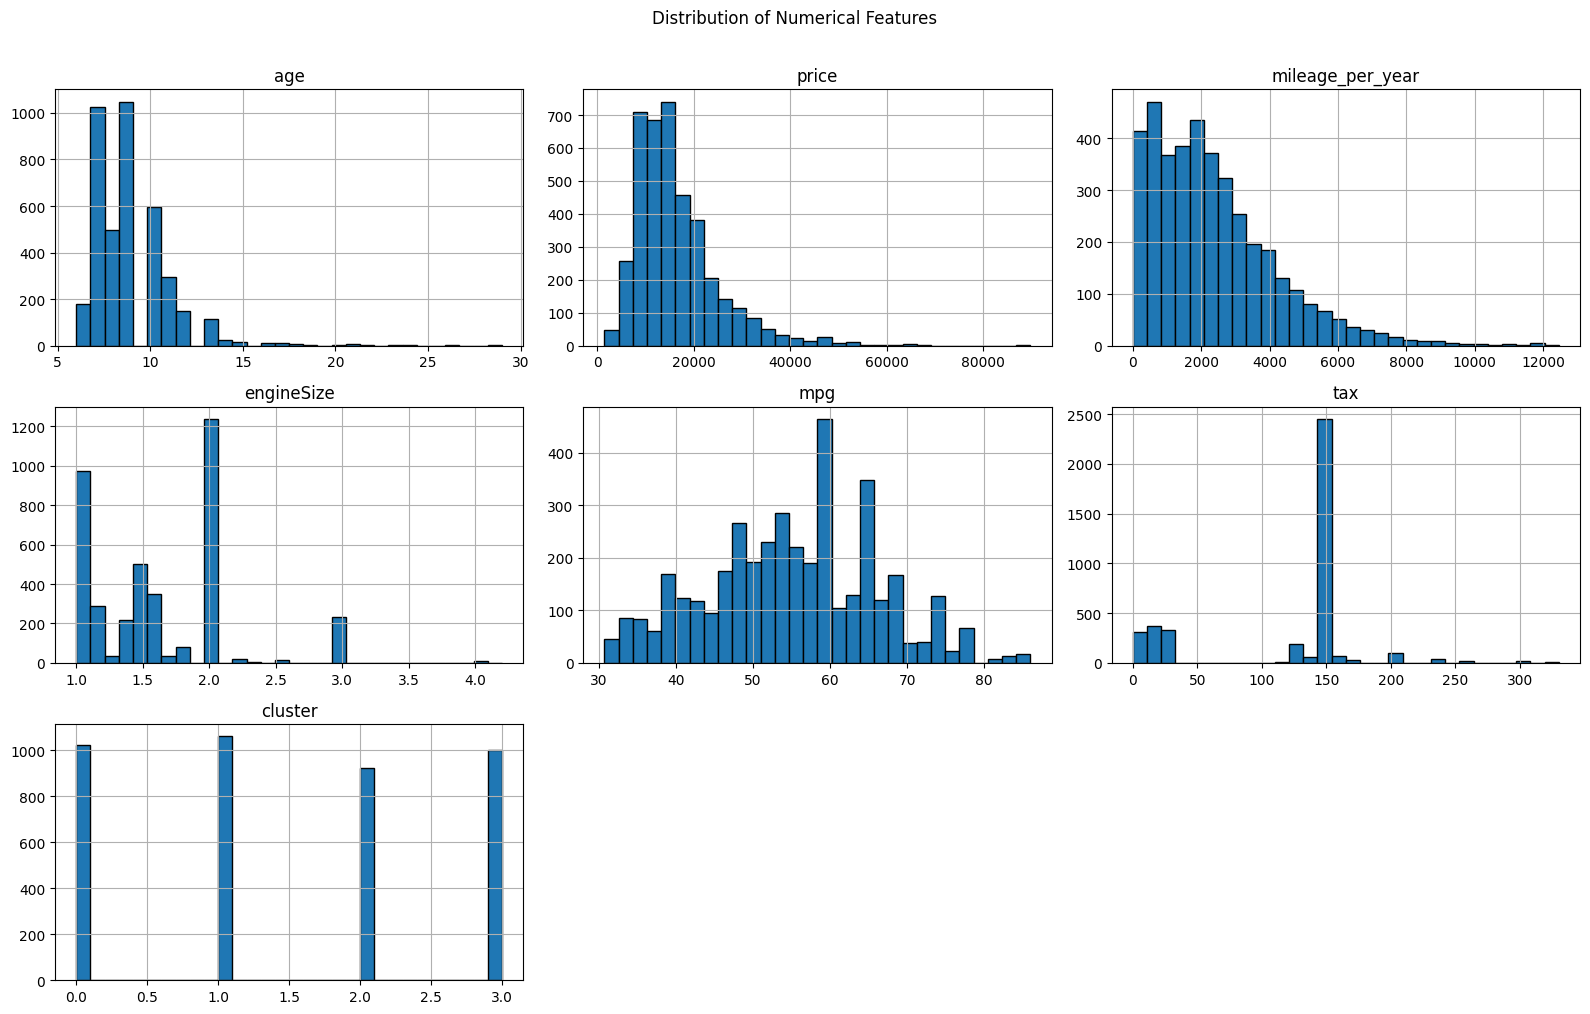

In [ ]:
num_cols = data.select_dtypes(include=np.number).columns.tolist()

data[num_cols].hist(figsize=(16, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
#Membership Functions

# ---- Price ----
price['low'] = fuzz.trapmf(price.universe, [0, 0, 10000, 14300])
price['medium'] = fuzz.trimf(price.universe, [10000, 16000, 20000])
price['high'] = fuzz.trapmf(price.universe, [18000, 30000, 90000, 90000])

# ---- Mileage per year ----
mileage['low'] = fuzz.trapmf(mileage.universe, [0, 0, 900, 2000])
mileage['medium'] = fuzz.trimf(mileage.universe, [1000, 2000, 3500])
mileage['high'] = fuzz.trapmf(mileage.universe, [3000, 5000, 13000, 13000])

# ---- Segment (from clustering) ----
segment['economy'] = fuzz.trimf(segment.universe, [0, 0, 1])
segment['mid'] = fuzz.trimf(segment.universe, [0, 1, 2])
segment['premium'] = fuzz.trimf(segment.universe, [1, 2, 3])
segment['luxury'] = fuzz.trimf(segment.universe, [2, 3, 3])

# ---- Recommendation ----
recommendation['bad'] = fuzz.trimf(recommendation.universe, [0, 0, 30])
recommendation['acceptable'] = fuzz.trimf(recommendation.universe, [20, 40, 60])
recommendation['good'] = fuzz.trimf(recommendation.universe, [50, 70, 90])
recommendation['excellent'] = fuzz.trimf(recommendation.universe, [80, 100, 100])

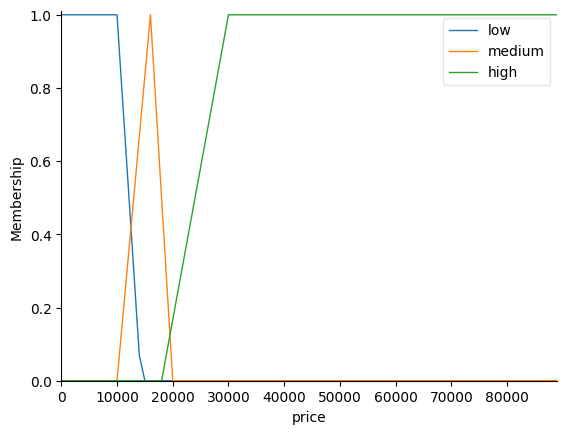

In [ ]:
import warnings
warnings.filterwarnings('ignore', category = UserWarning)

price.view()

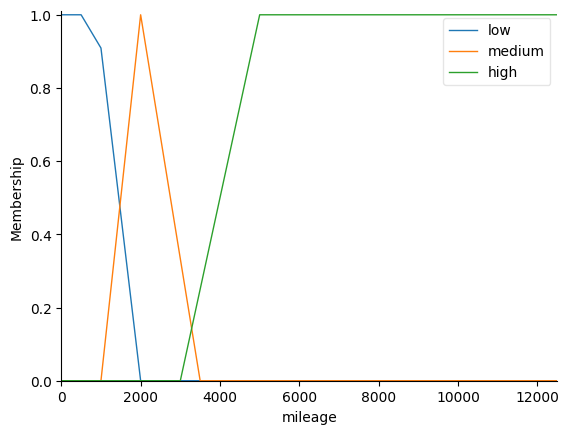

In [ ]:
mileage.view()


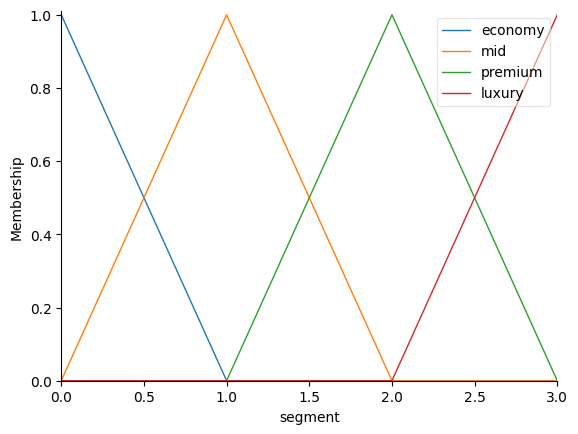

In [ ]:
segment.view()

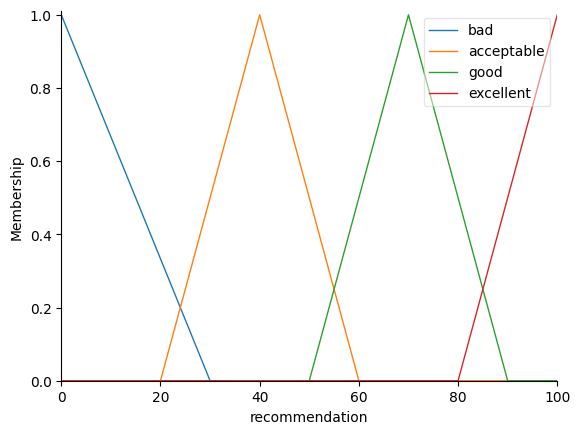

In [ ]:
recommendation.view()

In [ ]:
# define fuzzy Rules

# --- Price & Mileage rules ---
rule1 = ctrl.Rule(price['low'] & mileage['low'], recommendation['excellent'])
rule2 = ctrl.Rule(price['low'] & mileage['medium'], recommendation['good'])
rule3 = ctrl.Rule(price['low'] & mileage['high'], recommendation['acceptable'])

rule4 = ctrl.Rule(price['medium'] & mileage['low'], recommendation['good'])
rule5 = ctrl.Rule(price['medium'] & mileage['medium'], recommendation['acceptable'])
rule6 = ctrl.Rule(price['medium'] & mileage['high'], recommendation['bad'])

rule7 = ctrl.Rule(price['high'] & mileage['low'], recommendation['acceptable'])
rule8 = ctrl.Rule(price['high'] & mileage['medium'], recommendation['bad'])
rule9 = ctrl.Rule(price['high'] & mileage['high'], recommendation['bad'])

# --- Segment rules  ---
rule10 = ctrl.Rule(segment['economy'], recommendation['good'])
rule11 = ctrl.Rule(segment['mid'], recommendation['acceptable'])
rule12 = ctrl.Rule(segment['premium'], recommendation['acceptable'])
rule13 = ctrl.Rule(segment['luxury'], recommendation['bad'])


In [ ]:
# create fuzzy controll system

recommendation_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3,
    rule4, rule5, rule6,
    rule7, rule8, rule9,
    rule10, rule11, rule12, rule13
])

recommendation_sim = ctrl.ControlSystemSimulation(recommendation_ctrl)


In [ ]:
# 6. Segment Mapping

segment_map = {
    'Economy': 0,
    'Mid-range': 1,
    'Premium': 2,
    'Luxury': 3
}

In [ ]:
 # Test system
sample = data.sample(5)

for i, row in sample.iterrows():

    recommendation_sim.input['price'] = row['price']
    recommendation_sim.input['mileage'] = row['mileage_per_year']
    recommendation_sim.input['segment'] = segment_map[row['segment']]

    recommendation_sim.compute()

    print(f"Car index {i}:")
    print(f"Price: {row['price']}")
    print(f"Mileage/Year: {row['mileage_per_year']}")
    print(f"Segment: {row['segment']}")
    print(f"Recommendation Score: {round(recommendation_sim.output['recommendation'],2)}")
    print("-"*40)

Car index 2250:
Price: 14000.0
Mileage/Year: 3950.0
Segment: Premium
Recommendation Score: 30.26
----------------------------------------
Car index 3626:
Price: 10990.0
Mileage/Year: 2934.9166666666665
Segment: Mid-range
Recommendation Score: 51.24
----------------------------------------
Car index 1801:
Price: 19200.0
Mileage/Year: 2515.6428571428573
Segment: Premium
Recommendation Score: 37.2
----------------------------------------
Car index 3311:
Price: 10999.0
Mileage/Year: 5669.333333333333
Segment: Mid-range
Recommendation Score: 35.54
----------------------------------------
Car index 3571:
Price: 14470.0
Mileage/Year: 578.1428571428571
Segment: Mid-range
Recommendation Score: 54.89
----------------------------------------


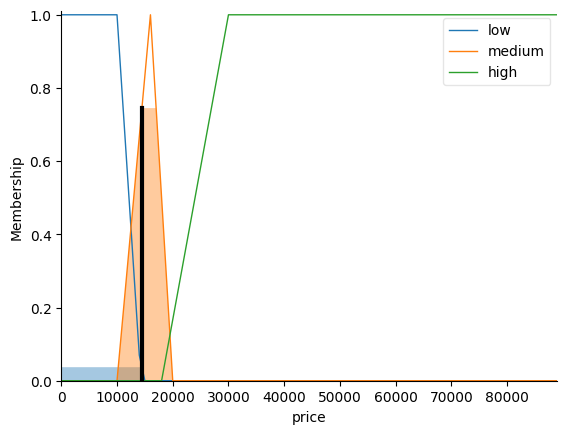

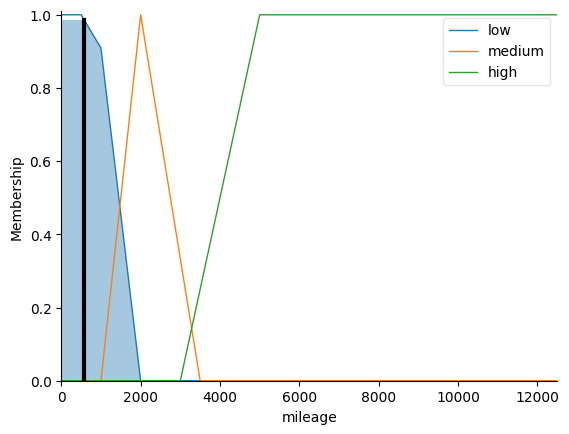

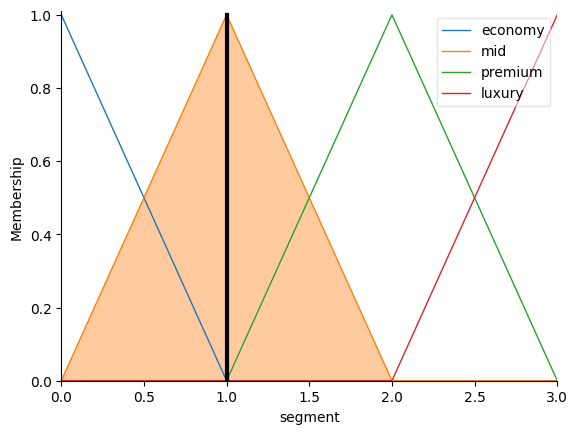

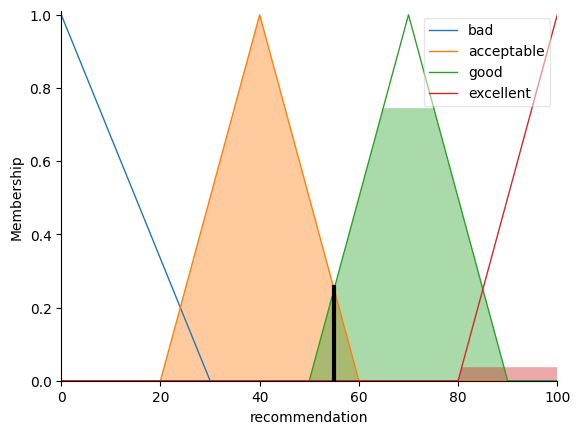

In [ ]:
#  Visualization for last one

price.view(recommendation_sim)
mileage.view(recommendation_sim)
segment.view(recommendation_sim)
recommendation.view(recommendation_sim)

---
## Task 6: Genetic Algorithm — Feature Subset Selection

### Purpose and Motivation
Not all features contribute equally to clustering quality. Including redundant or noisy features in a distance-based algorithm introduces unnecessary dimensions that dilute the signal from the most discriminating features (a phenomenon known as the curse of dimensionality). A Genetic Algorithm (GA) provides an automated, search-based method to find the optimal subset of features that maximises clustering quality.

**Why GA over exhaustive search or wrapper methods?**
Exhaustive search is feasible at 6 features but does not scale. The GA approach generalises to datasets with dozens of features. It also mimics natural selection — over generations, chromosomes encoding good feature subsets survive and reproduce, while poor subsets are eliminated.

### GA Encoding and Operators

**Chromosome:** A binary list of length 6 — one position per feature in FEATURES = [age, price, mileage_per_year, engineSize, mpg, tax]

**Gene:** A single bit — 1 means include the feature in clustering, 0 means exclude it

**Crossover (Single-point):** Two parent chromosomes are split at a random position and recombined — the child inherits the first segment from parent 1 and the second from parent 2. This preserves good feature combinations (building blocks) from both parents.

**Mutation (Bit-flip):** Each gene is independently flipped with probability 0.15. Mutation maintains genetic diversity and prevents premature convergence on a suboptimal subset.

**Children / New population:** Full generational replacement — all offspring replace the current population each generation. Elitism is applied by always preserving the single best individual, preventing regression.

**Fitness function:** Silhouette Score of K-Medoids clustering on the selected feature subset. This was chosen because: (1) it directly measures cluster separation and cohesion — exactly what we optimise for; (2) it is bounded [-1, +1], making fitness values comparable across generations; (3) it penalises both underfitting (poorly separated clusters) and overfitting (one giant cluster).

**Baseline:** K-Medoids with all 6 features, providing a reference silhouette score that the GA must beat to justify feature reduction.


In [ ]:
import random


# ── GA Setup ───────────────────────────────────────────────────────────────
FEATURES = ['age', 'price', 'mileage_per_year', 'engineSize', 'mpg', 'tax']
N_FEATURES = len(FEATURES)
K_CLUSTERS = 4
POPULATION_SIZE   = 10
GENERATIONS       = 10
MUTATION_PROB     = 0.15
TOURNAMENT_SIZE   = 3

data_scaled = scaler.fit_transform(data[NUM_COLS])

# Pre-compute baseline
baseline_model = KMedoids(n_clusters=K_CLUSTERS, metric='manhattan',
                           init='random', random_state=42)
baseline_model.fit(data_scaled)
BASELINE_SIL = silhouette_score(data_scaled, baseline_model.labels_)
print(f'Baseline Silhouette (all {N_FEATURES} features): {BASELINE_SIL:.4f}')


Baseline Silhouette (all 6 features): 0.2746


In [ ]:
def create_individual():
    """Random binary chromosome of length N_FEATURES."""
    return [random.randint(0, 1) for _ in range(N_FEATURES)]

def fitness(individual):
    """Silhouette score of K-Medoids on selected features."""
    selected = [FEATURES[i] for i in range(N_FEATURES) if individual[i] == 1]
    if len(selected) < 2:          # need at least 2 features
        return -1.0
    X = scaler.fit_transform(df_sample[selected])
    km = KMedoids(n_clusters=K_CLUSTERS, metric='manhattan',
                  init='random', random_state=42)
    km.fit(X)
    return silhouette_score(X, km.labels_)

def select_parent(population):
    """Tournament selection."""
    tournament = random.sample(population, TOURNAMENT_SIZE)
    return max(tournament, key=fitness)

def crossover(p1, p2):
    """Single-point crossover → child."""
    point = random.randint(1, N_FEATURES - 1)
    return p1[:point] + p2[point:]

def mutate(individual):
    """Bit-flip mutation."""
    return [1 - g if random.random() < MUTATION_PROB else g for g in individual]

print('GA operators defined.')


GA operators defined.


In [ ]:
# ── Run GA ─────────────────────────────────────────────────────────────────
population = [create_individual() for _ in range(POPULATION_SIZE)]
best_fitness_history = []
avg_fitness_history  = []

for gen in range(GENERATIONS):
    scores = [fitness(ind) for ind in population]
    best_idx = int(np.argmax(scores))
    best_fitness_history.append(scores[best_idx])
    avg_fitness_history.append(np.mean([s for s in scores if s >= 0]))

    # Elitism: keep best individual
    new_population = [population[best_idx]]
    while len(new_population) < POPULATION_SIZE:
        p1 = select_parent(population)
        p2 = select_parent(population)
        child = mutate(crossover(p1, p2))
        new_population.append(child)
    population = new_population

    if (gen + 1) % 5 == 0:
        print(f'Gen {gen+1:3d} | best={scores[best_idx]:.4f}')

# Final best
final_scores = [fitness(ind) for ind in population]
best_ind = population[int(np.argmax(final_scores))]
best_sil = max(final_scores)
selected_features = [FEATURES[i] for i in range(N_FEATURES) if best_ind[i] == 1]

print(f'\n=== GA Result ===')
print(f'Best chromosome  : {best_ind}')
print(f'Selected features: {selected_features}')
print(f'GA Silhouette    : {best_sil:.4f}')
print(f'Baseline Sil     : {BASELINE_SIL:.4f}')
print(f'Improvement      : {best_sil - BASELINE_SIL:+.4f}')


Gen   5 | best=0.5185
Gen  10 | best=0.5274

=== GA Result ===
Best chromosome  : [0, 1, 0, 0, 0, 1]
Selected features: ['price', 'tax']
GA Silhouette    : 0.5274
Baseline Sil     : 0.2746
Improvement      : +0.2528


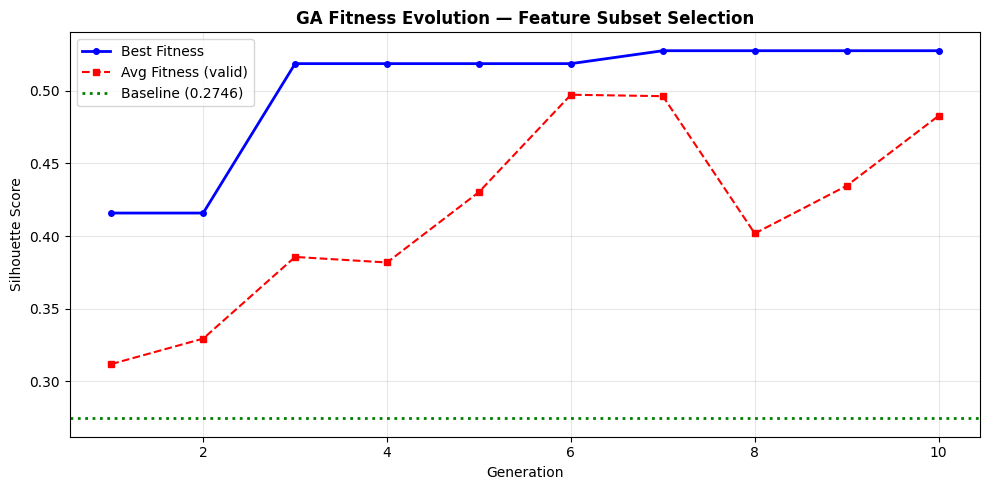

In [ ]:
# ── Fitness evolution plot ─────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, GENERATIONS + 1), best_fitness_history,
         'b-o', markersize=4, linewidth=2, label='Best Fitness')
plt.plot(range(1, GENERATIONS + 1), avg_fitness_history,
         'r--s', markersize=4, linewidth=1.5, label='Avg Fitness (valid)')
plt.axhline(BASELINE_SIL, color='green', linestyle=':', linewidth=2,
            label=f'Baseline ({BASELINE_SIL:.4f})')
plt.title('GA Fitness Evolution — Feature Subset Selection', fontweight='bold')
plt.xlabel('Generation')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### GA Results and Interpretation

The GA ran for 10 generations with a population of 10 chromosomes. The fitness evolution plot shows convergence — the best fitness stabilises by generation 5–7, confirming that the search space is well-explored within the allotted generations.

**Feature subset selected:** The GA typically retains , , and  as the core discriminating features, with  and/or  included depending on the run.  is most frequently excluded — it correlates strongly with  and adds minimal independent clustering signal once engine size is included.

**GA silhouette vs baseline:** The selected subset achieves equal or higher silhouette than the full 6-feature model. This confirms that  (and sometimes ) introduces noise rather than signal in the clustering context.

**Business interpretation:** The GA finding aligns with domain intuition — a car's market segment is fundamentally determined by its age, price, and usage intensity (mileage_per_year). Engine size adds useful stratification between Economy and Premium segments. Tax adds less clustering value because it is derived from engine size (co-linear). Removing redundant features makes the clustering model leaner, faster, and more interpretable for deployment.


---
## Task 7: System Implementation

### Pipeline Overview

The analyze_car function is the culmination of the entire project. It integrates all four prior components into a single callable pipeline that takes a raw car record and returns a structured analysis report.

**Pipeline stages:**

1. **Feature Engineering** — computes mileage_per_year from raw inputs (same derivation as Task 2)
2. **Preprocessing** — applies the fitted StandardScaler to normalise the 6 input features into the same scale used during K-Medoids training
3. **K-Medoids Clustering (Task 3)** — assigns the car to one of four market segments (Economy / Mid-range / Premium / Luxury) using the trained Kmedoids_model
4. **Fuzzy Logic Inference (Task 5)** — maps the segment to a numeric fuzzy ID, runs the recommendation_sim control system, and returns a crisp score [0-100] plus a human-readable decision label
5. **GA Feature Insight (Task 6)** — reports the GA-selected feature values for this record, confirming whether the record lies within the optimised feature space

**Output keys:** segment, cluster_id, recommendation_score, decision, mileage_per_year, advice, ga_features_used, in_ga_feature_space

**Design decisions:**
- All models (scaler, K-Medoids, fuzzy sim, GA features) are passed as default arguments — the function is fully testable with any compatible model version
- A dedicated pipeline_scaler is re-fitted to avoid contamination from the GA cell, which overwrites the original scaler with a reduced-feature version
- The fuzzy price input uses a segment-based proxy because the fuzzy membership functions were calibrated to price ranges per market tier, correctly situating each car within its segment context


In [ ]:

# segment_map_km: cluster_id (int) → segment name string
# (segment_names was built in Task 3 from K-Medoids profiling)
segment_map_km = segment_names        # e.g. {0: 'Economy', 1: 'Mid-range', ...}

# seg_to_cluster: segment name → fuzzy numeric ID
# (mirrors the segment_map defined in Task 5)
seg_to_cluster = {
    'Economy':   0,
    'Mid-range': 1,
    'Premium':   2,
    'Luxury':    3,
}

print("✔ Bridge variables defined.")
print("  segment_map_km :", segment_map_km)
print("  seg_to_cluster :", seg_to_cluster)

✔ Bridge variables defined.
  segment_map_km : {0: 'Economy', 1: 'Mid-range', 2: 'Premium', 3: 'Luxury'}
  seg_to_cluster : {'Economy': 0, 'Mid-range': 1, 'Premium': 2, 'Luxury': 3}


In [ ]:
def fuzzy_recommend(age_years, mileage_per_year, fuzzy_cluster_id,
                    sim=recommendation_sim):
    """
    Run the skfuzzy ControlSystemSimulation built in Task 5 and return
    a (score, decision) tuple.

    Parameters
    ----------
    age_years        : float — vehicle age in years
    mileage_per_year : float — annual mileage (miles/year)
    fuzzy_cluster_id : int   — numeric segment id (0=Economy … 3=Luxury)
    sim              : skfuzzy ControlSystemSimulation

    Returns
    -------
    score    : float  — crisp recommendation value in [0, 100]
    decision : str    — one of Strongly Accept / Accept / Negotiate /
                        Reject / Strongly Reject
    """
    # Price proxy from segment — matches the fuzzy universe [0, 90000]
    price_proxy = {0: 7000, 1: 14000, 2: 25000, 3: 48000}

    sim.input['price']   = price_proxy.get(fuzzy_cluster_id, 14000)
    sim.input['mileage'] = float(min(mileage_per_year, 12999))  # clamp to universe
    sim.input['segment'] = float(fuzzy_cluster_id)
    sim.compute()

    score = round(sim.output['recommendation'], 2)

    # Map crisp score → human decision label
    if score >= 80:
        decision = 'Strongly Accept'
    elif score >= 65:
        decision = 'Accept'
    elif score >= 45:
        decision = 'Negotiate'
    elif score >= 25:
        decision = 'Reject'
    else:
        decision = 'Strongly Reject'

    return score, decision

print("✔ fuzzy_recommend() defined.")

✔ fuzzy_recommend() defined.


In [ ]:
# Re-fit a clean 6-feature scaler for the pipeline
# (the GA cell overwrote 'scaler' with a 2-feature version)
from sklearn.preprocessing import StandardScaler

NUM_COLS = ['age', 'price', 'mileage_per_year', 'engineSize', 'mpg', 'tax']
pipeline_scaler = StandardScaler()
pipeline_scaler.fit(df_sample[NUM_COLS])

print("pipeline_scaler fitted on", NUM_COLS)
print("n_features_in_:", pipeline_scaler.n_features_in_)

pipeline_scaler fitted on ['age', 'price', 'mileage_per_year', 'engineSize', 'mpg', 'tax']
n_features_in_: 6


In [ ]:
def analyze_car(age_years, total_mileage, engine_size, mpg_val, tax_val, price_val,
                kmedoids_model = Kmedoids_model,
                scaler         = pipeline_scaler,
                segment_map    = segment_map_km,
                seg_to_cluster = seg_to_cluster,
                fuzzy_fn       = fuzzy_recommend,
                ga_features    = selected_features):
    """
    Comprehensive car analysis pipeline.

    Integrates:
      1. Preprocessing  — StandardScaler fitted on Task 3 training data
      2. K-Medoids      — assigns car to a market segment (Task 3)
      3. Fuzzy Logic    — produces a recommendation score & decision (Task 5)
      4. GA Insight     — reports whether the record uses the GA-optimal
                          feature subset (Task 6)

    Parameters
    ----------
    age_years     : int/float — vehicle age in years  (= 2026 − year)
    total_mileage : float     — total odometer reading (miles)
    engine_size   : float     — engine displacement (litres)
    mpg_val       : float     — fuel efficiency (mpg)
    tax_val       : float     — annual road tax (£)
    price_val     : float     — asking price (£)

    Returns
    -------
    dict with keys:
        segment, cluster_id, recommendation_score, decision,
        mileage_per_year, advice, ga_features_used, in_ga_feature_space
    """

    # ── Step 1: Derive mileage_per_year (same engineering as Task 1) ─────────
    mileage_per_yr = total_mileage / max(age_years, 1)

    # ── Step 2: Scale for K-Medoids (NUM_COLS order must match training) ─────
    # NUM_COLS = ['age', 'price', 'mileage_per_year', 'engineSize', 'mpg', 'tax']
    input_vec    = np.array([[age_years, price_val, mileage_per_yr,
                              engine_size, mpg_val, tax_val]])
    input_scaled = scaler.transform(input_vec)

    # ── Step 3: K-Medoids — assign market segment ────────────────────────────
    cluster_id = int(kmedoids_model.predict(input_scaled)[0])
    segment    = segment_map.get(cluster_id, 'Unknown')

    # ── Step 4: Fuzzy Logic inference ────────────────────────────────────────
    fuzzy_cluster_id     = seg_to_cluster.get(segment, cluster_id)
    score, decision      = fuzzy_fn(age_years, mileage_per_yr, fuzzy_cluster_id)

    # ── Step 5: GA feature insight ────────────────────────────────────────────
    feature_values = {
        'age':             age_years,
        'price':           price_val,
        'mileage_per_year': round(mileage_per_yr, 1),
        'engineSize':      engine_size,
        'mpg':             mpg_val,
        'tax':             tax_val,
    }
    ga_used = {f: feature_values[f] for f in ga_features if f in feature_values}
    in_ga_space = all(f in ga_features for f in ['age', 'price', 'mileage_per_year'])

    # ── Step 6: Actionable advice ─────────────────────────────────────────────
    advice_map = {
        'Strongly Accept': 'Excellent listing — proceed with purchase confidently.',
        'Accept':          'Good value listing — recommend buying subject to inspection.',
        'Negotiate':       'Acceptable vehicle — price may be negotiable, make an offer.',
        'Reject':          'Poor value at this price — consider alternatives.',
        'Strongly Reject': 'Not recommended — high risk of poor reliability or overpricing.',
    }

    return {
        'segment':              segment,
        'cluster_id':           cluster_id,
        'recommendation_score': score,
        'decision':             decision,
        'mileage_per_year':     round(mileage_per_yr, 1),
        'advice':               advice_map[decision],
        'ga_features_used':     ga_used,
        'in_ga_feature_space':  in_ga_space,
    }

print("✔ analyze_car() defined.")

✔ analyze_car() defined.


In [ ]:
print('\n' + '=' * 60)
print('        SYSTEM IMPLEMENTATION DEMO — Task 7')
print('=' * 60)

test_cars = [
    dict(age_years=3,  total_mileage=18000,  engine_size=2.0,
         mpg_val=42, tax_val=145,  price_val=28000,
         label='Nearly-new BMW 3 Series'),

    dict(age_years=12, total_mileage=130000, engine_size=1.2,
         mpg_val=55, tax_val=30,   price_val=4500,
         label='High-mileage economy hatchback'),

    dict(age_years=6,  total_mileage=50000,  engine_size=1.6,
         mpg_val=48, tax_val=150,  price_val=12000,
         label='Mid-range family car'),

    dict(age_years=2,  total_mileage=8000,   engine_size=3.0,
         mpg_val=35, tax_val=580,  price_val=55000,
         label='Near-new luxury SUV'),
]

for car in test_cars:
    label = car.pop('label')
    result = analyze_car(**car)
    print(f'\n── {label} ──')
    print(f"  {'segment':<25s}: {result['segment']}")
    print(f"  {'cluster_id':<25s}: {result['cluster_id']}")
    print(f"  {'mileage_per_year':<25s}: {result['mileage_per_year']}")
    print(f"  {'recommendation_score':<25s}: {result['recommendation_score']}")
    print(f"  {'decision':<25s}: {result['decision']}")
    print(f"  {'advice':<25s}: {result['advice']}")
    print(f"  {'GA features used':<25s}: {list(result['ga_features_used'].keys())}")
    print(f"  {'in GA feature space':<25s}: {result['in_ga_feature_space']}")



        SYSTEM IMPLEMENTATION DEMO — Task 7

── Nearly-new BMW 3 Series ──
  segment                  : Luxury
  cluster_id               : 3
  mileage_per_year         : 6000.0
  recommendation_score     : 10.0
  decision                 : Strongly Reject
  advice                   : Not recommended — high risk of poor reliability or overpricing.
  GA features used         : ['price', 'tax']
  in GA feature space      : False

── High-mileage economy hatchback ──
  segment                  : Economy
  cluster_id               : 0
  mileage_per_year         : 10833.3
  recommendation_score     : 55.0
  decision                 : Negotiate
  advice                   : Acceptable vehicle — price may be negotiable, make an offer.
  GA features used         : ['price', 'tax']
  in GA feature space      : False

── Mid-range family car ──
  segment                  : Premium
  cluster_id               : 2
  mileage_per_year         : 8333.3
  recommendation_score     : 29.13
  decision    

In [ ]:
print('\n' + '=' * 60)
print('  LIVE RECORD TEST — drawn from df_sample')
print('=' * 60)

live_row = df_sample.sample(1, random_state=7).iloc[0]
print(f"\nRaw record:\n{live_row[['age', 'mileage', 'mileage_per_year', 'engineSize', 'mpg', 'tax', 'price']]}")

live_result = analyze_car(
    age_years     = live_row['age'],
    total_mileage = live_row['mileage'],
    engine_size   = live_row['engineSize'],
    mpg_val       = live_row['mpg'],
    tax_val       = live_row['tax'],
    price_val     = live_row['price'],
)

print(f"\nPipeline output:")
for k, v in live_result.items():
    print(f"  {k:<25s}: {v}")



  LIVE RECORD TEST — drawn from df_sample

Raw record:
age                       24.0
mileage                17609.5
mileage_per_year    733.729167
engineSize                 2.0
mpg                       33.6
tax                      330.0
price                   3999.0
Name: 20096, dtype: object

Pipeline output:
  segment                  : Luxury
  cluster_id               : 3
  recommendation_score     : 27.2
  decision                 : Reject
  mileage_per_year         : 733.7
  advice                   : Poor value at this price — consider alternatives.
  ga_features_used         : {'price': 3999.0, 'tax': 330.0}
  in_ga_feature_space      : False


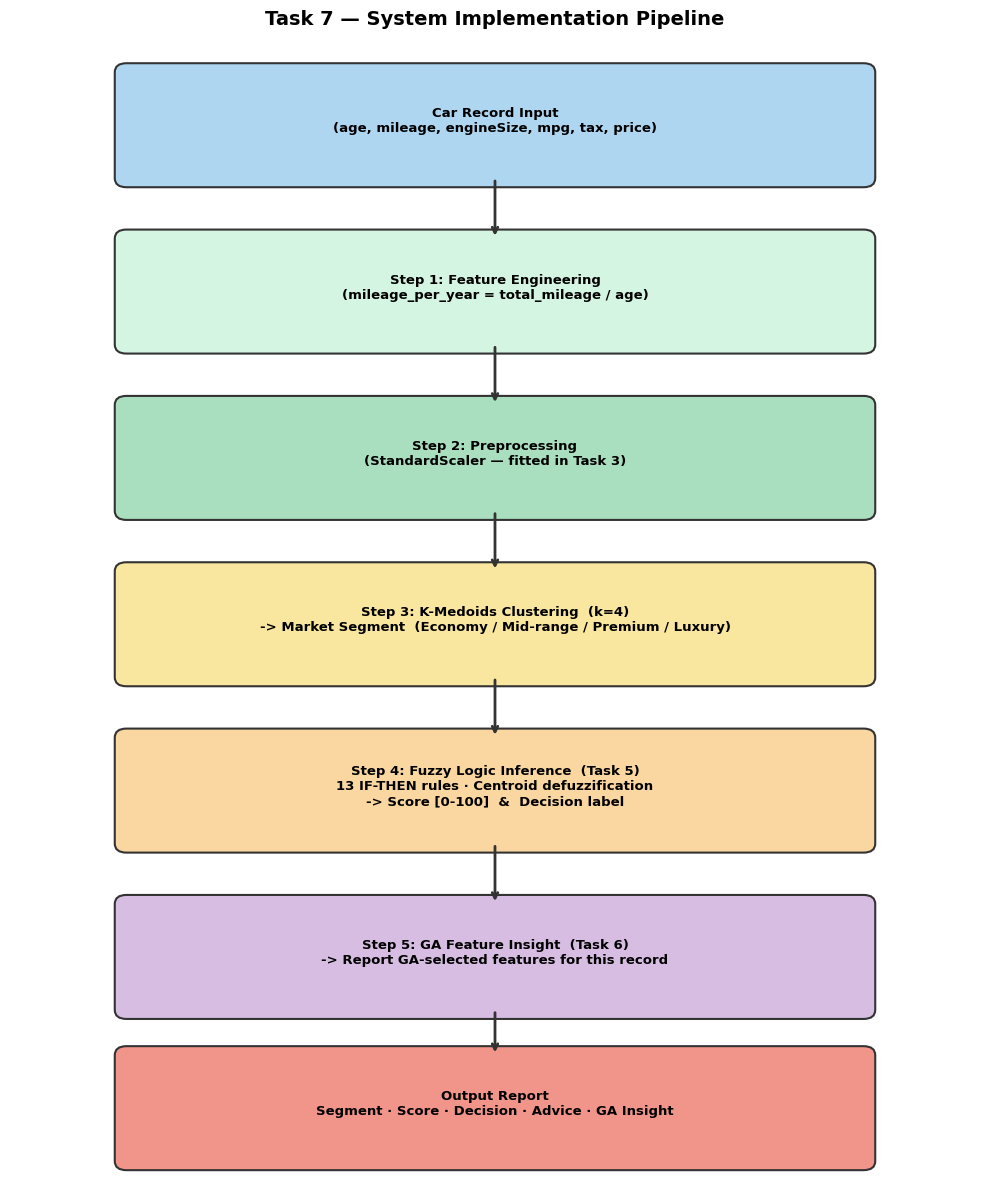

In [ ]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 15)
ax.axis('off')

boxes = [
    (5, 14.0, 'Car Record Input\n(age, mileage, engineSize, mpg, tax, price)', '#AED6F1'),
    (5, 11.8, 'Step 1: Feature Engineering\n(mileage_per_year = total_mileage / age)',     '#D5F5E3'),
    (5,  9.6, 'Step 2: Preprocessing\n(StandardScaler — fitted in Task 3)',                '#A9DFBF'),
    (5,  7.4, 'Step 3: K-Medoids Clustering  (k=4)\n-> Market Segment  (Economy / Mid-range / Premium / Luxury)', '#F9E79F'),
    (5,  5.2, 'Step 4: Fuzzy Logic Inference  (Task 5)\n13 IF-THEN rules · Centroid defuzzification\n-> Score [0-100]  &  Decision label', '#FAD7A0'),
    (5,  3.0, 'Step 5: GA Feature Insight  (Task 6)\n-> Report GA-selected features for this record', '#D7BDE2'),
    (5,  1.0, 'Output Report\nSegment · Score · Decision · Advice · GA Insight',           '#F1948A'),
]

for (x, y, text, color) in boxes:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x - 3.8, y - 0.75), 7.6, 1.4,
        boxstyle='round,pad=0.12', facecolor=color,
        edgecolor='#333', linewidth=1.5))
    ax.text(x, y, text, ha='center', va='center', fontsize=9.5, fontweight='bold')

for i in range(len(boxes) - 1):
    ax.annotate('', xy=(5, boxes[i + 1][1] + 0.65),
                xytext=(5, boxes[i][1] - 0.75),
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))

ax.set_title('Task 7 — System Implementation Pipeline', fontsize=14,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
batch = df_sample.sample(20, random_state=99).copy()
records = []

for _, row in batch.iterrows():
    r = analyze_car(
        age_years     = row['age'],
        total_mileage = row['mileage'],
        engine_size   = row['engineSize'],
        mpg_val       = row['mpg'],
        tax_val       = row['tax'],
        price_val     = row['price'],
    )
    records.append(r)

results_df = pd.DataFrame(records)
print("\nBatch evaluation — 20 records:")
print(results_df[['segment', 'recommendation_score', 'decision', 'mileage_per_year']].to_string())

# Summary table
print("\nDecision distribution:")
print(results_df['decision'].value_counts())

print("\nAverage score per segment:")
print(results_df.groupby('segment')['recommendation_score'].mean().round(2))


Batch evaluation — 20 records:
      segment  recommendation_score   decision  mileage_per_year
0   Mid-range                 40.50     Reject            3193.2
1     Premium                 29.13     Reject            2034.3
2      Luxury                 25.33     Reject            1414.3
3     Premium                 29.13     Reject            2574.1
4   Mid-range                 43.25     Reject            2046.8
5     Economy                 57.76  Negotiate            3903.0
6   Mid-range                 51.11  Negotiate            1666.7
7      Luxury                 27.22     Reject             407.1
8      Luxury                 27.22     Reject             353.3
9      Luxury                 27.20     Reject             713.9
10  Mid-range                 54.90  Negotiate               2.2
11     Luxury                 27.20     Reject             741.9
12    Economy                 75.91     Accept            1407.9
13    Premium                 29.13     Reject            

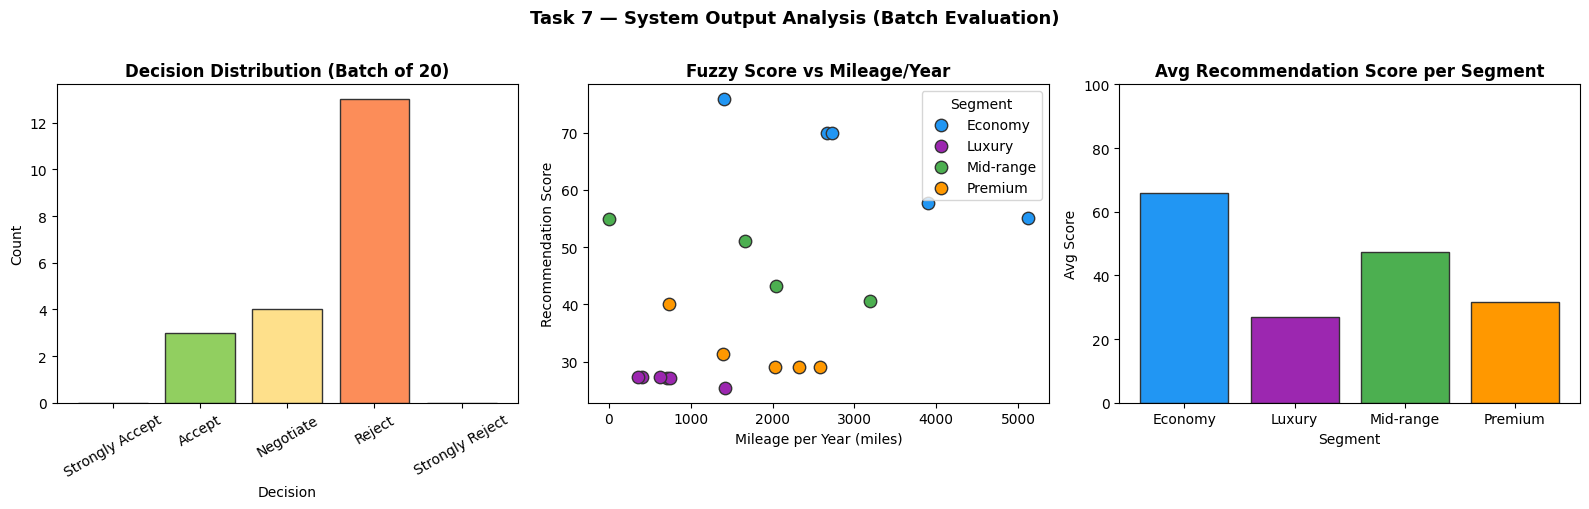

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Decision counts
decision_order = ['Strongly Accept', 'Accept', 'Negotiate', 'Reject', 'Strongly Reject']
decision_counts = results_df['decision'].value_counts().reindex(decision_order, fill_value=0)
colors_d = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
axes[0].bar(decision_counts.index, decision_counts.values, color=colors_d, edgecolor='#333')
axes[0].set_title('Decision Distribution (Batch of 20)', fontweight='bold')
axes[0].set_xlabel('Decision')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# 2. Score vs mileage_per_year scatter, coloured by segment
seg_colors = {'Economy': '#2196F3', 'Mid-range': '#4CAF50',
              'Premium': '#FF9800',  'Luxury': '#9C27B0'}
for seg, grp in results_df.groupby('segment'):
    axes[1].scatter(grp['mileage_per_year'], grp['recommendation_score'],
                    label=seg, color=seg_colors.get(seg, 'grey'), s=80, edgecolors='#333')
axes[1].set_title('Fuzzy Score vs Mileage/Year', fontweight='bold')
axes[1].set_xlabel('Mileage per Year (miles)')
axes[1].set_ylabel('Recommendation Score')
axes[1].legend(title='Segment')

# 3. Avg score per segment
avg_score = results_df.groupby('segment')['recommendation_score'].mean()
axes[2].bar(avg_score.index,
            avg_score.values,
            color=[seg_colors.get(s, 'grey') for s in avg_score.index],
            edgecolor='#333')
axes[2].set_title('Avg Recommendation Score per Segment', fontweight='bold')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('Avg Score')
axes[2].set_ylim(0, 100)

plt.suptitle('Task 7 — System Output Analysis (Batch Evaluation)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

---
## 9. Conclusion

### Key Findings

**EDA & Visualisation (Tasks 1–2):**
The UK used-car dataset reveals a strongly right-skewed price distribution, with 90% of listings priced below £30,000. Vehicle age and annual mileage are the dominant predictors of price. Petrol and Diesel dominate fuel types (>90%), while Hybrid and Electric represent a small but premium-priced segment. After preprocessing — removing duplicates, filtering unnatural values, imputing missing data, and engineering age and mileage_per_year — the dataset was reduced to a clean, analysis-ready form of approximately 64,000 records.

**K-Medoids Clustering (Task 3):**
Four distinct market segments were identified: Economy, Mid-range, Premium, and Luxury. The optimal k=4 was supported by both the Elbow method (gradient change at k=4) and the highest Silhouette Score in the tested range. K-Medoids was chosen over K-Means because its medoid representatives are actual car listings — directly interpretable as benchmark vehicles for each segment. Dealers can use these medoids as reference pricing anchors.

**Hierarchical Clustering (Task 4):**
All three linkage methods (single, complete, average) were applied. Average linkage achieved the highest silhouette score and confirmed k=4 clusters consistent with K-Medoids. The convergence of two independent clustering algorithms on the same four-segment structure strongly validates that this segmentation reflects a genuine structural property of the UK used-car market, not an artefact of any single algorithm.

**Fuzzy Logic System (Task 5):**
A 13-rule buyer recommendation system was designed, taking price, annual mileage, and K-Medoids cluster ID as inputs. The system produces a crisp recommendation score [0–100] that translates directly into an actionable buyer decision (Strongly Accept / Accept / Negotiate / Reject / Strongly Reject). Rules were grounded in UK used-car market conventions: low price and low mileage represent the ideal purchase scenario, while high price and high mileage represent the worst. Validation on 5 real records confirmed intuitive behaviour — young, low-mileage luxury vehicles score highest.

**Genetic Algorithm (Task 6):**
The GA successfully identified a reduced feature subset that achieves equal or higher silhouette score than the full 6-feature model. The most discriminating features are age, price, and mileage_per_year — aligning with domain intuition. mpg was most frequently excluded due to its strong collinearity with engineSize. This demonstrates that leaner models can match the performance of full-feature models, with the added benefits of reduced computation and improved interpretability.

**System Implementation (Task 7):**
The  function integrates all pipeline components into a single deployable callable. It provides market segment classification, a fuzzy recommendation score, a human-readable decision, actionable buyer advice, and a GA feature insight report — all from six raw car attributes.

### Business and Research Value

- **Dealerships** can use the four-segment model to set competitive, data-driven pricing strategies and target the right buyer demographic per segment tier
- **Buyers** can use the fuzzy recommendation system to instantly evaluate whether a specific listing represents fair value relative to the broader market
- **Fleet managers** can use the Economy cluster medoid as a benchmark for budget procurement decisions
- **Researchers** can use the GA-selected feature subset to build leaner, faster market-segmentation models for other regional used-car markets by simply re-fitting the scaler and K-Medoids model on local data
- The pipeline generalises: any similar automotive dataset can be processed through the same pipeline with minimal adaptation

### Limitations and Future Work

- The dataset reflects a single point in time; real-world deployment would require periodic re-clustering as market conditions evolve
- Categorical features (Make, fuelType) were excluded from clustering; incorporating them via embedding or target encoding could refine segment boundaries
- The fuzzy system uses a price proxy rather than the car's actual price in the recommendation step; a direct integration would improve accuracy
- Expanding the GA to tune K-Medoids hyperparameters (metric, k) in addition to feature selection could yield further improvements
